# Rare Object Detection — Embedding Evaluation & Active Learning

This notebook evaluates the quality of learned embeddings across training runs that vary several hyperparameters:
- **Label fraction `f`**: fraction of the training set that carries morphological labels (0 = fully unsupervised, 1 = fully labelled)
- **Supervision weight `sw`**: relative weight of the supervised contrastive loss term
- **`vicregvar`**, **`cov`**, **`gamma`**: VICReg loss coefficients (variance, covariance, and EMA-target gamma)

Retrieval quality is measured with **nDCG@10** per morphological class. The second half of the notebook runs **Protege** Gaussian-Process active learning on the resulting embeddings to efficiently surface rare/interesting radio galaxies.

All dependencies are installed and imported in the first code cell.

In [1]:
import re
import subprocess
import sys
import torch

# Install dependencies only if missing
def _install(*packages):    
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

try:
    import astronomaly
except ModuleNotFoundError:
    _install("git+https://github.com/MichelleLochner/astronomaly.git")

try:
    import pyarrow
except ModuleNotFoundError:
    _install("pyarrow", "fastparquet", "numpy<2")

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    _install("ipywidgets")
    import ipywidgets as widgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as _mcm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from pathlib import Path
from collections import defaultdict
from scipy.spatial.distance import cdist
import json
import hashlib
import traceback
import warnings

import umap
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest as _IsoForest
from sklearn.linear_model import LogisticRegression as _LR
from skimage.feature import blob_doh as _blob_doh

import astronomaly
from astronomaly.anomaly_detection import protege
from astronomaly.feature_extraction import shape_features as _sf
from astronomaly.base.base_dataset import Dataset as _AstroDataset

from IPython.display import display, clear_output

print("astronomaly version:", astronomaly.__version__)
print("numpy version:", np.__version__)
print("pyarrow version:", pyarrow.__version__)

%matplotlib inline

astronomaly version: 2.0
numpy version: 2.4.6
pyarrow version: 24.0.0


## 1. Configuration

Set top-level paths, glob patterns, and evaluation parameters used throughout the notebook. Adjust `OUTPUTS_ROOT`, `RUN_GLOB`, and the data paths to match your local setup.

In [2]:
def _get_diagonal_seed_dirs(run_name_dir):
    """Return training_seed_N dirs where data_seed == training_seed, filtered to DATA_SEEDS."""
    result = []
    for ds_dir in sorted(run_name_dir.glob("data_seed_*")):
        n = int(ds_dir.name.split("_")[-1])
        if DATA_SEEDS is not None and n not in DATA_SEEDS:
            continue
        ts_dir = ds_dir / f"training_seed_{n}"
        if ts_dir.is_dir():
            result.append(ts_dir)
    return result


def _get_cv_fold_dirs(run_name_dir):
    """Return cross_val_K leaf dirs for data_seed_2/training_seed_2/ (5-fold CV)."""
    ts_dir = run_name_dir / "data_seed_2" / "training_seed_2"
    if not ts_dir.is_dir():
        return []
    return sorted(ts_dir.glob("cross_val_*"), key=lambda p: int(p.name.split("_")[-1]))


def _cv_splits_dir(fold_dir):
    """Return data_splits/2/cross_val_K/ for a given CV fold dir."""
    return OUTPUTS_ROOT / "data_splits" / "2" / fold_dir.name


# ── Config ───────────────────────────────────────────────────────────────────
ROOT           = Path("/users/mbredber/p3_SUPLAT")
OUTPUTS_ROOT   = ROOT / "outputs"
BYOL_RUNS_ROOT = OUTPUTS_ROOT / "byol_runs" / "byol_runs"
RUN_GLOB       = "pd128_qext_v1_wd1e-3_lrconst_sw*_f*"
EVAL_SPLIT     = "test"    # split used for nDCG evaluation
N_CLASSES      = 20        # number of label dimensions
NDCG_K         = 10        # k in nDCG@k

CSV_PATH        = ROOT / "data/metadata/lotss_classifications_horton_et_al_2025_filtered.csv"
CUTOUT_DIR      = ROOT / "data/raw/lotss_cutouts"
LABELS_NPY_PATH = ROOT / "data/preprocessed/lotss/labels_filtered.npy"
IMAGES_PATH     = ROOT / "data/preprocessed/lotss/images_filtered.npy"

# ── Seed selection ────────────────────────────────────────────────────────────
DATA_SEEDS = [2]  # use data_seed=2 with 5-fold cross-validation

# ── Protege run selection ─────────────────────────────────────────────────────
F_LABEL            = 1     # label fraction of the run to analyse
SUPERVISION_WEIGHT = 0.05  # supervision weight of the run to analyse
RUN_NAME_FILTER    = ""   # optional substring to disambiguate; leave "" to pick latest

_run_glob_specific = RUN_GLOB.replace("sw*_f*", f"sw{SUPERVISION_WEIGHT}_f{F_LABEL}")
_matching = sorted(BYOL_RUNS_ROOT.glob(_run_glob_specific))
if RUN_NAME_FILTER:
    _matching = [r for r in _matching if RUN_NAME_FILTER in r.name]
assert len(_matching) >= 1, (
    f"No runs found matching f={F_LABEL} sw={SUPERVISION_WEIGHT} filter={RUN_NAME_FILTER!r}"
)
if len(_matching) > 1:
    print(f"Warning: {len(_matching)} runs match — using the latest:")
    for r in _matching:
        print(f"  {r.name}")
_run_dir = _matching[-1]   # latest by sorted name (date suffix); may be a family dir

# Resolve to the actual run dir: prefer CV fold 0, fall back to first diagonal seed
_cv_folds = _get_cv_fold_dirs(_run_dir)
_diag_dirs = _get_diagonal_seed_dirs(_run_dir)
_run_dir_actual = _cv_folds[0] if _cv_folds else (_diag_dirs[0] if _diag_dirs else _run_dir)
RUN_DIR = str(_run_dir_actual / "data")
print(f"RUN_DIR: {RUN_DIR}")

# ── Protege active-learning hyperparameters ───────────────────────────────────
USE_ENCODINGS = False  # If True, load encodings instead of projections for the GP pipeline
APPLY_PCA = True      # Whether to apply PCA before Protege; set to False to use original features

# Tag encoding latent-space type + PCA choice — used in file/figure names
_latent_tag = ("enc" if USE_ENCODINGS else "proj") + ("_pca" if APPLY_PCA else "")
INITIAL_STEPS  = 200   # initial evenly-spaced seed labels (only used when running from scratch)
STEPS_PER_ITER = 100   # labels acquired per GP iteration (matches --steps in train_byol_proteges.py)
EPSILON        = 2.0  # Higher ε means more exploration, lower ε means more exploitation. Paper default is 2. Set to 0 to disable exploration and run pure exploitation (greedy acquisition of top-uncertainty samples).

# ── Scoring & display ─────────────────────────────────────────────────────────
POSITIVE_THRESHOLD = 3       # sources with human_label >= this are "interesting"
FORCE_SAVE_FIGS    = False   # set True to overwrite already-saved figures


RUN_DIR: /users/mbredber/p3_SUPLAT/outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2/cross_val_0/data


## 2. Representational Space

Characterises the geometry and retrieval quality of the learned BYOL embedding space. Run sections in order:

- **§2.1** — load split embeddings and labels
- **§2.2** — encoder vs projector AUC comparison (f = 1, sw sweep)
- **§2.3** — UMAP coloured by interest score
- **§2.4** — kNN retrieval gallery for each SCORE_4 class
- **§2.5** — nDCG@10 per morphological class across a run sweep
- **§2.6** — ellipse-fit IsoForest unsupervised baseline
- **§2.7** — nDCG@10 broken down by interest tier × feature space

#### Class Index Mapping

Based on the LoTSS classifications (Horton et al. 2025), the 20-dimensional
label vector corresponds to the following classes:

| Index | Column          | Classification       | Type        | N sources |
|-------|-----------------|----------------------|-------------|-----------|
| 0     | `fri`           | FRI                  | Initial     | 2992      |
| 1     | `frii`          | FRII                 | Initial     | 6231      |
| 2     | `hybrid`        | Hybrids              | Initial     | 966       |
| 3     | `spiral`        | Spirals              | Initial     | 234       |
| 4     | `relaxed`       | Relaxed doubles      | Initial     | 440       |
| 5     | `cshaped`       | C-curvature          | Morphology  | 2379      |
| 6     | `sshaped`       | S-curvature          | Morphology  | 1082      |
| 7     | `misaligned`    | Misalignment         | Morphology  | 1287      |
| 8     | `wings`         | Wings                | Morphology  | 1564      |
| 9     | `xshaped`       | X-shaped             | Morphology  | 179       |
| 10    | `straight`      | Straight jets        | Morphology  | 358       |
| 11    | `multihotspots` | Multiple hotspots    | Morphology  | 2040      |
| 12    | `continuous`    | Continuous jets      | Morphology  | 337       |
| 13    | `banding`       | Banding              | Morphology  | 133       |
| 14    | `onesided`      | One-sided            | Morphology  | 23        |
| 15    | `restarted`     | Restarted            | Morphology  | 193       |
| 16    | `cluster`       | Cluster              | Environment | 72        |
| 17    | `merger`        | Merger               | Environment | 63        |
| 18    | `diffuse`       | Diffuse emission     | Environment | 111       |
| 19    | `unknown`       | Unknown              | Environment | 126       |

### Protege interest scoring

Each source is assigned the score of its most interesting label (multi-label sources take the highest applicable score).
Counts are from the full 7596-row dataset (`labels_filtered.npy`), before any train/val/test split.
Positives (score ≥ 3): **1303** (17.2%).

| Score | Label(s) | Count | % |
|-------|----------|-------|---|
| 4 | `xshaped`, `unknown`, `cluster`, `merger` | 285 | 3.8% |
| 3 | `diffuse`, `sshaped`, `spiral` | 1018 | 13.4% |
| 2 | `restarted`, `onesided`, `banding`, `cshaped`, `wings`, `misaligned`, `multihotspots`, `relaxed` | 3480 | 45.8% |
| 1 | `fri`, `frii`, `hybrid`, `straight`, `continuous`, (none of the above) | 2813 | 37.0% |
| **Total** | | **7596** | **100%** |

In [3]:
LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]  # must match the column order used when labels_filtered.npy was saved

SCORE_4 = ["xshaped", "unknown", "cluster", "merger"]
SCORE_3 = ["diffuse", "sshaped", "spiral"]
SCORE_2 = ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "multihotspots", "relaxed"]
SCORE_1 = ["fri", "frii", "hybrid", "straight", "continuous"]

# Canonical colour palette for the 6 initial morphology classes
_CLASS_PALETTE = {
    "FRI":              "#1f77b4",  # blue
    "FRII":             "#d62728",  # red
    "Hybrids":          "#9467bd",  # purple
    "Spirals":          "#2ca02c",  # green
    "Relaxed doubles":  "#ff7f0e",  # orange
    "Multi-label/none": "#7f7f7f",  # grey (catch-all)
}

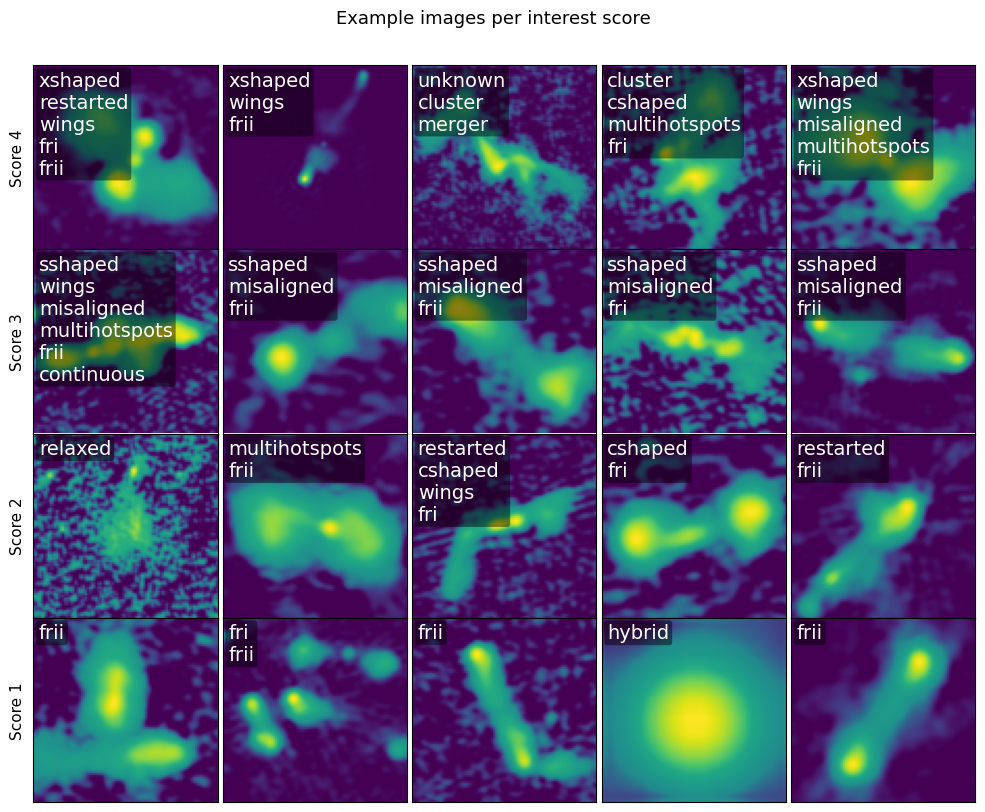

In [4]:
# Show 5 example images for each interest score (1–4)
if 'images_all' not in vars():
    images_all = np.load(IMAGES_PATH)

# Fallback: load split variables from full dataset if Cell 9 hasn't been run yet
if 'idx_arr' not in vars():
    idx_arr = np.arange(len(images_all))
if 'labels_npy_df' not in vars():
    _labels_all_tmp = np.load(LABELS_NPY_PATH)
    labels_npy_df = pd.DataFrame(_labels_all_tmp[idx_arr].astype(bool), columns=LABEL_COLS)
if 'human_labels' not in vars():
    _TIERS_TMP = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2)]
    human_labels = np.ones(len(labels_npy_df), dtype=int)
    for _sv, _cols in reversed(_TIERS_TMP):
        human_labels[labels_npy_df[_cols].any(axis=1).values] = _sv

images = images_all[idx_arr]  # align with current split

ALL_MORPH_COLS = SCORE_4 + SCORE_3 + SCORE_2 + SCORE_1

N_EXAMPLES = 5
scores = [4, 3, 2, 1]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(scores), N_EXAMPLES, figsize=(N_EXAMPLES * 2, len(scores) * 2),
                         gridspec_kw=dict(hspace=0, wspace=0))

for row, score in enumerate(scores):
    idxs = np.where(human_labels == score)[0]
    chosen = rng.choice(idxs, size=min(N_EXAMPLES, len(idxs)), replace=False)
    for col in range(N_EXAMPLES):
        ax = axes[row, col]
        if col < len(chosen):
            img = images[chosen[col]]
            if img.ndim == 3:
                img = img[0]  # take first channel if multi-channel
            ax.imshow(img, cmap='viridis', origin='lower')
            # Class labels: all True morphology columns for this source
            row_data = labels_npy_df.iloc[chosen[col]]
            active = [c for c in ALL_MORPH_COLS if row_data.get(c, False)]
            label_str = "\n".join(active) if active else "none"
            ax.text(0.03, 0.97, label_str, transform=ax.transAxes,
                    fontsize=14, color="white", va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.45, lw=0))
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"Score {score}", fontsize=11, labelpad=6)

fig.suptitle("Example images per interest score", fontsize=13, y=1.01)
plt.tight_layout()
_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "example_images_by_score.png", dpi=150, bbox_inches="tight")
_pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
_pdf_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_pdf_dir / "example_images_by_score.pdf", bbox_inches="tight")
plt.show()

### 2.1 Load Embeddings

Reads the projection embeddings and row indices for the selected run, joins to the source catalogue CSV to recover `Source_Name` and per-class morphology flags, and converts the multi-label flags into a 1–4 human-interest score (4 = rarest/most exotic morphology).

In [5]:
RUN_DIR_ = Path(RUN_DIR)

# ── Derive shared splits directory ────────────────────────────────────────────
_run_dir_root = RUN_DIR_.parent   # strip the /data suffix added in the config cell
_ckpt_for_seed = torch.load(_run_dir_root / "byol_model_best.pt",
                             map_location="cpu", weights_only=False)
_data_seed_  = int(_ckpt_for_seed["config"]["data_seed"])
# If running from a CV fold dir (cross_val_K), use fold-specific splits.
# Otherwise fall back to the seed-level splits dir.
if _run_dir_root.name.startswith("cross_val"):
    _splits_dir_ = OUTPUTS_ROOT / "data_splits" / str(_data_seed_) / _run_dir_root.name
else:
    _splits_dir_ = OUTPUTS_ROOT / "data_splits" / str(_data_seed_)

# Derive f-string matching the filename suffix used by train_byol.py
_f_label_ = _ckpt_for_seed["config"].get("f_label", F_LABEL)
_f_str_   = str(_f_label_).rstrip('0').rstrip('.') if '.' in str(_f_label_) else str(int(_f_label_))

def _load_idx_(name):
    """Load idx array: tries f-suffixed version first (new runs), then base name, then data_dir (old runs)."""
    stem, ext = name.rsplit('.', 1)
    p_fsuffix = _splits_dir_ / f"{stem}_f{_f_str_}.{ext}"
    p_base    = _splits_dir_ / name
    if p_fsuffix.exists():
        return np.load(p_fsuffix)
    elif p_base.exists():
        return np.load(p_base)
    else:
        return np.load(RUN_DIR_ / name)

def _load_base_idx(name):
    """Load idx array from base (non-f-suffixed) split file only."""
    p = _splits_dir_ / name
    return np.load(p if p.exists() else RUN_DIR_ / name)

# Feature files are in data/byol/ (new runs) or data/ (old runs)
_byol_dir_ = RUN_DIR_ / "byol" if (RUN_DIR_ / "byol").exists() else RUN_DIR_

# ── Load features + indices (handles f=0, f=1, and mixed 0<f<1) ─────────────
# USE_ENCODINGS selects encodings vs projections; both are saved by train_byol.py.
# For 0<f<1: labelled-only file; combine with unlabelled.
# For f=0: labelled file holds ALL train features (no unlabelled file).
# For f=1: all train sources are labelled — load from labelled files.
_feat_suffix     = "encodings" if USE_ENCODINGS else "projections"
_lab_proj        = np.load(_byol_dir_ / f"labelled_train_{_feat_suffix}.npy")
_lab_idx         = _load_idx_("labelled_train_idx.npy")
_unlab_idx       = _load_idx_("unlabelled_train_idx.npy")
_unlab_proj_path = _byol_dir_ / f"unlabelled_train_{_feat_suffix}.npy"

if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    projections = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    idx_arr     = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0: labelled_train_projections.npy contains all train projections
    projections = _lab_proj
    idx_arr     = _unlab_idx
else:                       # f=1: all sources are labelled
    projections = _lab_proj
    idx_arr     = _lab_idx

# ── Shape consistency check ───────────────────────────────────────────────────
# The f-suffixed idx files (e.g. labelled_train_idx_f1.npy) may contain only
# the Protege human-labeled budget set (a subset of all train sources), while
# the feature .npy files contain ALL train sources.  If sizes disagree, fall
# back to the base (non-f-suffixed) idx files which define the full train split.
if len(projections) != len(idx_arr):
    print(f"  WARNING: projections ({len(projections)}) ≠ idx_arr ({len(idx_arr)}) — "
          f"f-suffixed idx files are Protege budget files, not full-split files. "
          f"Falling back to base idx files.")
    _lab_idx_base   = _load_base_idx("labelled_train_idx.npy")
    _unlab_idx_base = _load_base_idx("unlabelled_train_idx.npy")
    if len(_lab_idx_base) > 0 and len(_unlab_idx_base) > 0:
        idx_arr = np.concatenate([_lab_idx_base, _unlab_idx_base])
    elif len(_lab_idx_base) == 0:
        idx_arr = _unlab_idx_base
    else:
        idx_arr = _lab_idx_base
    assert len(idx_arr) == len(projections), (
        f"idx_arr ({len(idx_arr)}) still does not match projections ({len(projections)}) "
        f"after falling back to base idx files.")
    print(f"  Resolved: idx_arr now has {len(idx_arr)} entries.")

print(f"features ({_feat_suffix}): {projections.shape}  idx_arr: {idx_arr.shape}")
print(f"idx_arr max value: {idx_arr.max()}")
print(f"idx_arr min value: {idx_arr.min()}")
print(f"Any idx >= 7596 (npy length): {(idx_arr >= 7596).sum()}")

# Load CSV only for Source_Name — row order matches images_filtered.npy for the first 7596 rows
csv_df       = pd.read_csv(CSV_PATH)
source_names = csv_df.iloc[idx_arr]["Source_Name"].values

features_df = pd.DataFrame(projections, index=source_names)

# ── Load labels from the aligned .npy file (NOT the CSV) ──────────────────
# images_filtered.npy and labels_filtered.npy are row-aligned companions.
# The CSV has 7607 rows vs 7596 in the npy files — they are NOT aligned,
# so csv_df.iloc[idx_arr] gives wrong labels. Use labels_filtered.npy instead.

labels_all   = np.load(LABELS_NPY_PATH)       # shape (7596, 20)
labels_split = labels_all[idx_arr]            # shape (N_split, 20) — aligned with projections

# Build a DataFrame for convenient column access
labels_npy_df = pd.DataFrame(labels_split.astype(bool), columns=LABEL_COLS)

# Build human_label (1–4) from tier scoring
TIERS = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2)]
human_labels = np.ones(len(labels_npy_df), dtype=int)
for score_val, cols in reversed(TIERS):
    mask = labels_npy_df[cols].any(axis=1).values
    human_labels[mask] = score_val

labels_df = pd.DataFrame({"human_label": human_labels}, index=source_names)

print("human_label distribution:")
print(pd.Series(human_labels).value_counts().sort_index())
binary_label = (human_labels >= 4).astype(int)
print(f"\nPositives (score≥4): {binary_label.sum()}  |  Negatives: {(binary_label==0).sum()}")

# ── Load test projections + labels (needed for UMAP and Protege eval) ────────
# test_idx.npy in the splits dir may only contain the Protege test budget (partial).
# When it is smaller than the test feature file, reconstruct the full test indices
# as the complement of the train indices within the dataset.
_test_idx  = _load_base_idx("test_idx.npy")
_test_proj = np.load(_byol_dir_ / f"test_{_feat_suffix}.npy")

if len(_test_idx) < len(_test_proj):
    _n_total       = labels_all.shape[0]   # 7596
    _train_idx_all = np.concatenate([
        _load_base_idx("labelled_train_idx.npy"),
        _load_base_idx("unlabelled_train_idx.npy"),
    ])
    _test_idx = np.setdiff1d(np.arange(_n_total), _train_idx_all)
    print(f"  test_idx derived from complement of train: {len(_test_idx)} entries")
    assert len(_test_idx) == len(_test_proj), (
        f"Derived test_idx ({len(_test_idx)}) ≠ test_proj ({len(_test_proj)})")

# Guard against drop_last truncation: test_projections may have fewer rows than test_idx
# (happens when the training script uses drop_last=True for the test loader)
_n_test = len(_test_proj)
if _n_test < len(_test_idx):
    print(f"  Warning: test_projections ({_n_test}) < test_idx ({len(_test_idx)}), trimming to match.")
    _test_idx = _test_idx[:_n_test]

_test_names = csv_df.iloc[_test_idx]["Source_Name"].values

_test_labels_raw = labels_all[_test_idx]
_test_labels_df  = pd.DataFrame(_test_labels_raw.astype(bool), columns=LABEL_COLS)
_test_human      = np.ones(len(_test_labels_df), dtype=int)
for _sv, _cols in reversed(TIERS):
    _test_human[_test_labels_df[_cols].any(axis=1).values] = _sv

labels_df = pd.concat([
    labels_df,
    pd.DataFrame({"human_label": _test_human}, index=_test_names),
])

# Combined train + test arrays (used by UMAP and PCA cells)
n_train   = len(projections)
all_proj  = np.concatenate([projections, _test_proj], axis=0)
all_names = np.concatenate([source_names, _test_names])

print(f"\nTest sources: {len(_test_idx)}  |  Total (train+test): {len(all_proj)}")


features (projections): (6076, 128)  idx_arr: (6076,)
idx_arr max value: 7595
idx_arr min value: 0
Any idx >= 7596 (npy length): 0
human_label distribution:
1    2263
2    2773
3     809
4     231
Name: count, dtype: int64

Positives (score≥4): 231  |  Negatives: 5845

Test sources: 1520  |  Total (train+test): 7596


sw values found: [0.0, 0.05, 0.1, 0.5, 1.0]
  sw=0.0  proj: 5 seed(s)  mean=0.6731 ± 0.0027
  sw=0.0  enc: 5 seed(s)  mean=0.6086 ± 0.0563
  sw=0.05  proj: 5 seed(s)  mean=0.6782 ± 0.0036
  sw=0.05  enc: 5 seed(s)  mean=0.6157 ± 0.0613
  sw=0.1  proj: 5 seed(s)  mean=0.6811 ± 0.0054
  sw=0.1  enc: 5 seed(s)  mean=0.5904 ± 0.0456
  sw=0.5  proj: 5 seed(s)  mean=0.6511 ± 0.0031
  sw=0.5  enc: 5 seed(s)  mean=0.5685 ± 0.0102
  sw=1.0  proj: 5 seed(s)  mean=0.6424 ± 0.0113
  sw=1.0  enc: 5 seed(s)  mean=0.5600 ± 0.0077


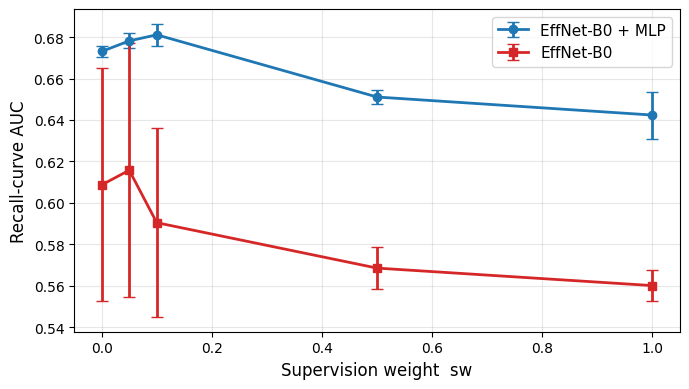

In [6]:
# ── Encoder vs Projector: AUC comparison across sw sweep (f = 1) ─────────────
# Reads protege_summary JSON files for both latent types from diagonal seed dirs.
# Note: protege results live at training_seed_N level (not inside cross_val_K),
# so we iterate all diagonal seeds directly, ignoring DATA_SEEDS.

_ep_latents = {"proj": "proj_nopca", "enc": "enc_pca"}
_ep_colors  = {"proj": "#1f77b4", "enc": "#d62728"}
_ep_markers = {"proj": "o", "enc": "s"}
_ep_labels  = {"proj": "EffNet-B0 + MLP", "enc": "EffNet-B0"}

# sw → latent → list of per-seed AUCs
_ep_data = {}

for _ep_run_dir in sorted(BYOL_RUNS_ROOT.glob("pd128_qext_v1_wd1e-3_lrconst_sw*_f1")):
    _m = re.search(r'_sw([\d.]+)_', _ep_run_dir.name)
    if _m is None:
        continue
    _sw = float(_m.group(1))
    # Iterate all diagonal seed dirs (data_seed_N/training_seed_N), not filtered by DATA_SEEDS,
    # because protege summaries exist per-seed rather than per CV fold.
    for _ds_dir in sorted(_ep_run_dir.glob("data_seed_*")):
        _n = int(_ds_dir.name.split("_")[-1])
        _sd = _ds_dir / f"training_seed_{_n}"
        if not _sd.is_dir():
            continue
        _prot_dir = _sd / "data" / "protege"
        for _lat, _tag in _ep_latents.items():
            _jpath = _prot_dir / f"protege_summary_{_tag}.json"
            if not _jpath.exists():
                continue
            with open(_jpath) as _fh:
                _js = json.load(_fh)
            _auc = _js.get("test_auc")
            if _auc is None:
                continue
            _ep_data.setdefault(_sw, {}).setdefault(_lat, []).append(_auc)

_ep_sw_vals = sorted(_ep_data)
print(f"sw values found: {_ep_sw_vals}")
for _sw in _ep_sw_vals:
    for _lat in _ep_latents:
        _aucs = _ep_data.get(_sw, {}).get(_lat, [])
        if _aucs:
            print(f"  sw={_sw}  {_lat}: {len(_aucs)} seed(s)  mean={np.mean(_aucs):.4f} ± {np.std(_aucs, ddof=1) if len(_aucs) > 1 else 0.0:.4f}")
        else:
            print(f"  sw={_sw}  {_lat}: no data")

# ── Plot ──────────────────────────────────────────────────────────────────────
if _ep_sw_vals:
    fig, ax = plt.subplots(figsize=(7, 4))

    for _lat, _tag in _ep_latents.items():
        _xs, _ys, _errs = [], [], []
        for _sw in _ep_sw_vals:
            _aucs = _ep_data.get(_sw, {}).get(_lat, [])
            if not _aucs:
                continue
            _xs.append(_sw)
            _ys.append(np.mean(_aucs))
            _errs.append(np.std(_aucs, ddof=1) if len(_aucs) > 1 else 0.0)
        ax.errorbar(_xs, _ys, yerr=_errs,
                    fmt=f"{_ep_markers[_lat]}-", color=_ep_colors[_lat],
                    linewidth=2, capsize=4, label=_ep_labels[_lat])

    ax.set_xlabel("Supervision weight  sw", fontsize=12)
    ax.set_ylabel("Recall-curve AUC", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    _ep_fig_dir = OUTPUTS_ROOT / "figures" / "enc_vs_proj"
    _ep_fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_ep_fig_dir / "enc_vs_proj_auc_sw.png", dpi=150, bbox_inches="tight")
    _pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
    _pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pdf_dir / "enc_vs_proj_auc_sw.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No data found. Run §3.4 sweep first (sbatch jobs/sbatch_byol_classifiers_dataseed.sh).")


### 2.3 UMAP by Interest Score

Fits a UMAP on the combined train+test BYOL projections and colours each source by its interest score (1–4). Isolated clusters (islands) are shown as inset zoom-ins with steelblue borders, using the same layout as the generative modelling notebook.

  Loading sw = 0.0: /users/mbredber/p3_SUPLAT/outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1/data_seed_2/training_seed_2


    Loaded UMAP cache (7596 sources)
    Done. Islands found: 1
  Loading sw = 0.05: /users/mbredber/p3_SUPLAT/outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2


    Loaded UMAP cache (7596 sources)
    Done. Islands found: 2
  Loading sw = 0.1: /users/mbredber/p3_SUPLAT/outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1/data_seed_2/training_seed_2


    Loaded UMAP cache (7596 sources)
    Done. Islands found: 2
  Loading sw = 0.5: /users/mbredber/p3_SUPLAT/outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1/data_seed_2/training_seed_2


    Loaded UMAP cache (7596 sources)
    Done. Islands found: 2


Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/umap_interest_score_sw_sweep.png


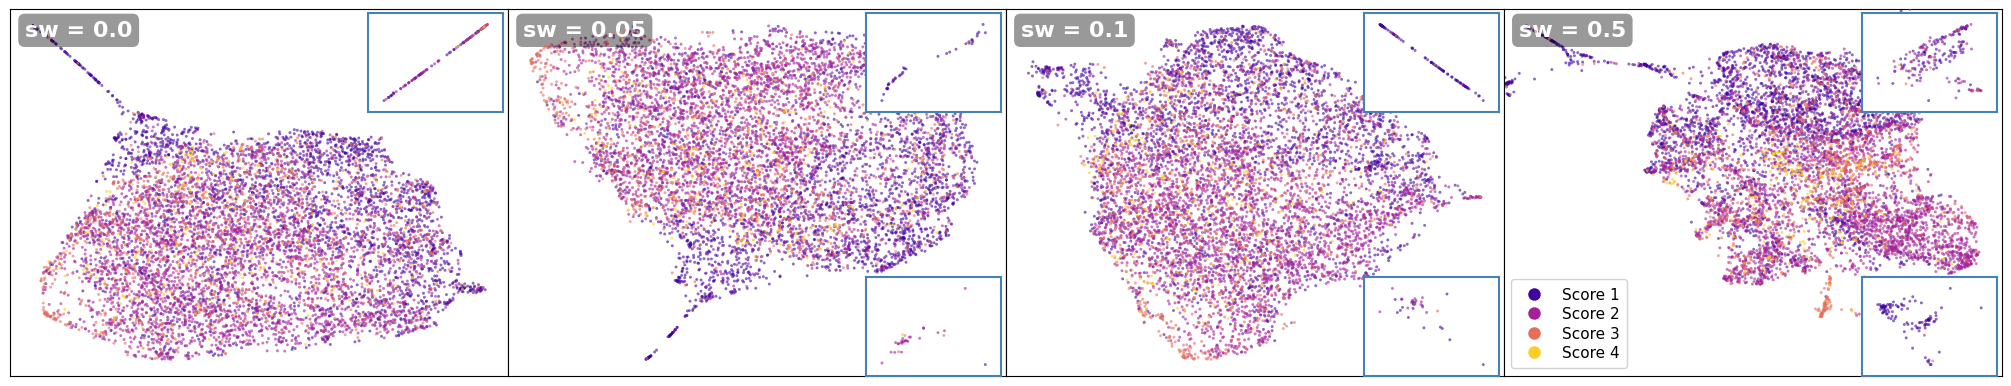

In [7]:
# ── Linear colour scale: plasma sampled evenly across scores 1–4 ──────────────
_SCORE_CMAP   = _mcm.plasma
_SCORE_COLORS = {s: _SCORE_CMAP(0.1 + 0.8 * (s - 1) / 3) for s in [1, 2, 3, 4]}
_SCORE_LABELS = {1: "Score 1", 2: "Score 2", 3: "Score 3", 4: "Score 4"}

# ── SW sweep config ───────────────────────────────────────────────────────────
_ROD_SW_VALS   = [0.0, 0.05, 0.1, 0.5]
_ROD_RUN_BASE  = "pd128_qext_v1_wd1e-3_lrconst_sw{sw}_f1"
_ROD_DATA_SEED = 2   # diagonal: data_seed_2 / training_seed_2

# ── Island detection ───────────────────────────────────────────────────────────
def _rod_find_islands(emb, eps_frac=0.04, min_samples=8):
    span = max(emb[:, 0].max() - emb[:, 0].min(), emb[:, 1].max() - emb[:, 1].min())
    labels = DBSCAN(eps=span * eps_frac, min_samples=min_samples).fit_predict(emb)
    if (labels == -1).any() and (labels >= 0).any():
        ids_labelled = np.unique(labels[labels >= 0])
        centres = np.array([emb[labels == k].mean(0) for k in ids_labelled])
        noise_pts = emb[labels == -1]
        nn = NearestNeighbors(n_neighbors=1).fit(centres)
        _, idx = nn.kneighbors(noise_pts)
        labels[labels == -1] = ids_labelled[idx.ravel()]
    uniq, cnt = np.unique(labels, return_counts=True)
    continent_id = uniq[np.argmax(cnt)]
    return labels, continent_id, [k for k in uniq if k != continent_id]

# ── Load projections + UMAP for each sw value ─────────────────────────────────
_sw_emb_data = {}   # sw_label → dict(emb, all_human, n_train, ...)

for _rod_sw in _ROD_SW_VALS:
    _rod_run_name = _ROD_RUN_BASE.format(sw=_rod_sw)
    _rod_run_dir  = BYOL_RUNS_ROOT / _rod_run_name
    _rod_sd       = _rod_run_dir / f"data_seed_{_ROD_DATA_SEED}" / f"training_seed_{_ROD_DATA_SEED}"

    if not _rod_run_dir.exists():
        print(f"MISSING run dir: {_rod_run_dir}")
        continue
    if not _rod_sd.exists():
        print(f"MISSING seed dir: {_rod_sd}")
        continue

    _sw_label = f"sw = {_rod_sw}"
    print(f"  Loading {_sw_label}: {_rod_sd}")

    _rod_ckpt     = torch.load(_rod_sd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    _rod_dseed    = int(_rod_ckpt["config"]["data_seed"])
    _rod_splits   = OUTPUTS_ROOT / "data_splits" / str(_rod_dseed)
    _rod_f        = float(_rod_ckpt["config"].get("f_label", 1.0))
    _rod_fstr     = str(int(_rod_f)) if _rod_f == int(_rod_f) else str(_rod_f)

    _rod_byol_d = _rod_sd / "data" / "byol" if (_rod_sd / "data" / "byol").exists() else _rod_sd / "data"

    def _rod_idx(name, _splits=_rod_splits, _fstr=_rod_fstr, _bd=_rod_byol_d):
        for p in [
            _splits / f"{name.replace('.npy', '')}_f{_fstr}.npy",
            _splits / name,
        ]:
            if p.exists(): return np.load(p)
        return np.load(_bd / name)

    _rod_lab_idx   = _rod_idx("labelled_train_idx.npy")
    _rod_unlab_idx = _rod_idx("unlabelled_train_idx.npy")
    _rod_ltp = np.load(_rod_byol_d / "labelled_train_projections.npy").astype(np.float32)
    _rod_ttp = np.load(_rod_byol_d / "test_projections.npy").astype(np.float32)

    _rod_unlab_p = _rod_byol_d / "unlabelled_train_projections.npy"
    if _rod_unlab_p.exists() and len(_rod_lab_idx) > 0 and len(_rod_unlab_idx) > 0:
        _rod_utp  = np.load(_rod_unlab_p).astype(np.float32)
        _rod_tr_proj = np.concatenate([_rod_ltp, _rod_utp])
        _rod_tr_idx  = np.concatenate([_rod_lab_idx, _rod_unlab_idx])
    elif len(_rod_lab_idx) == 0:
        _rod_tr_proj, _rod_tr_idx = _rod_ltp, _rod_unlab_idx
    else:
        _rod_tr_proj, _rod_tr_idx = _rod_ltp, _rod_lab_idx

    _rod_ti_path = _rod_splits / "test_idx.npy"
    _rod_ti = np.load(_rod_ti_path) if _rod_ti_path.exists() else np.array([], dtype=int)
    if len(_rod_ti) < len(_rod_ttp):
        _rod_ti = np.setdiff1d(np.arange(labels_all.shape[0]), _rod_tr_idx)
    _rod_ti = _rod_ti[:len(_rod_ttp)]

    def _rod_make_human(idx):
        _ldf = pd.DataFrame(labels_all[idx].astype(bool), columns=LABEL_COLS)
        _h = np.ones(len(_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _h[_ldf[_cols].any(axis=1).values] = _sv
        return _h

    _rod_all_proj  = np.concatenate([_rod_tr_proj, _rod_ttp], axis=0)
    _rod_all_human = np.concatenate([_rod_make_human(_rod_tr_idx), _rod_make_human(_rod_ti)])

    _rod_umap_cache = _rod_sd / "data" / "umap" / "umap_projections_coords.npy"
    if _rod_umap_cache.exists() and np.load(_rod_umap_cache).shape[0] == len(_rod_all_proj):
        _rod_emb = np.load(_rod_umap_cache)
        print(f"    Loaded UMAP cache ({len(_rod_emb)} sources)")
    else:
        print(f"    Fitting UMAP ({len(_rod_all_proj)} sources) …")
        _rod_red = umap.UMAP(random_state=42, n_neighbors=30, min_dist=0.1)
        _rod_emb = _rod_red.fit_transform(_rod_all_proj)

    _rod_cl, _rod_cid, _rod_iids = _rod_find_islands(_rod_emb)
    _sw_emb_data[_sw_label] = dict(emb=_rod_emb, all_human=_rod_all_human,
                                    cluster_labels=_rod_cl, continent_id=_rod_cid,
                                    island_ids=_rod_iids,
                                    n_train=len(_rod_tr_proj))
    print(f"    Done. Islands found: {len(_rod_iids)}")

if not _sw_emb_data:
    print("No data loaded — check that the sw sweep runs exist under BYOL_RUNS_ROOT.")
else:
    # ── Plot ───────────────────────────────────────────────────────────────────
    _sw_names   = list(_sw_emb_data)
    _n_panels   = len(_sw_names)
    _panel_size = 5.0
    _corners    = [(0.72, 0.72), (0.72, 0.00), (0.00, 0.72), (0.00, 0.00)]
    _inset_w    = 0.27
    _pt_size    = max(3, _panel_size * 0.9)

    fig, axes = plt.subplots(1, _n_panels,
                              figsize=(_panel_size * _n_panels, _panel_size * 0.75),
                              gridspec_kw={"wspace": 0.0})
    if _n_panels == 1:
        axes = [axes]

    _pad = lambda lo, hi, f: (lo - (hi - lo) * f, hi + (hi - lo) * f)

    for _ax, _slabel in zip(axes, _sw_names):
        _d   = _sw_emb_data[_slabel]
        _emb = _d["emb"]
        _ah  = _d["all_human"]
        _cl  = _d["cluster_labels"]
        _cid = _d["continent_id"]

        _cont_pts = _emb[_cl == _cid]
        _ax.set_xlim(_pad(_cont_pts[:, 0].min(), _cont_pts[:, 0].max(), 0.05))
        _ax.set_ylim(_pad(_cont_pts[:, 1].min(), _cont_pts[:, 1].max(), 0.05))

        for _score in [1, 2, 3, 4]:
            _mask = _ah == _score
            _ax.scatter(_emb[_mask, 0], _emb[_mask, 1],
                        c=[_SCORE_COLORS[_score]], s=_pt_size, alpha=0.6,
                        edgecolors="none", marker="o", zorder=_score + 1)

        _ax.text(0.03, 0.97, _slabel, transform=_ax.transAxes,
                 fontsize=16, color="white", va="top", ha="left", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.4, ec="none"))
        _ax.set_xticks([]); _ax.set_yticks([])

        for _iidx, _kid in enumerate(_d["island_ids"][:4]):
            _x0, _y0 = _corners[_iidx]
            _iax  = _ax.inset_axes([_x0, _y0, _inset_w, _inset_w])
            _imask = _cl == _kid
            _ipts  = _emb[_imask]
            if len(_ipts) > 0:
                _iax.set_xlim(_pad(_ipts[:, 0].min(), _ipts[:, 0].max(), 0.15))
                _iax.set_ylim(_pad(_ipts[:, 1].min(), _ipts[:, 1].max(), 0.15))
            for _score in [1, 2, 3, 4]:
                _smask = _imask & (_ah == _score)
                if _smask.any():
                    _iax.scatter(_emb[_smask, 0], _emb[_smask, 1],
                                 c=[_SCORE_COLORS[_score]], s=_pt_size, alpha=0.6,
                                 edgecolors="none", marker="o", zorder=_score + 1)
            _iax.set_xticks([]); _iax.set_yticks([])
            for _spine in _iax.spines.values():
                _spine.set_edgecolor("steelblue"); _spine.set_linewidth(1.5)

    _legend_handles = [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor=_SCORE_COLORS[s], markeredgecolor="none",
               markersize=9, label=_SCORE_LABELS[s])
        for s in [1, 2, 3, 4]
    ]
    axes[-1].legend(handles=_legend_handles, loc="lower left", fontsize=11,
                    framealpha=0.85, borderpad=0.5, labelspacing=0.3)

    plt.tight_layout(pad=0.3)
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    _umap_fig_path = _fig_dir / "umap_interest_score_sw_sweep.png"
    fig.savefig(_umap_fig_path, dpi=150, bbox_inches="tight")
    _pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
    _pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pdf_dir / _umap_fig_path.with_suffix(".pdf").name, bbox_inches="tight")
    print(f"Saved → {_umap_fig_path}")
    plt.show()


Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/umap_interest_score_sw_sweep_test.png


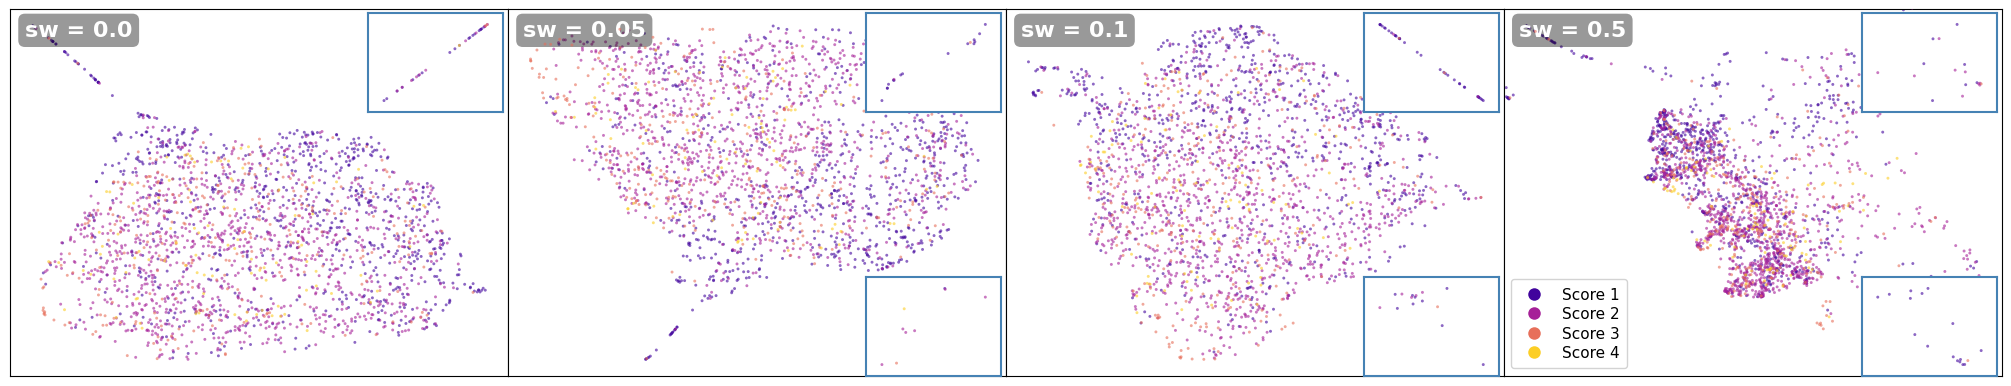

In [8]:
# ── UMAP by Interest Score — test set only, sw sweep ─────────────────────────
# Reuses embeddings from _sw_emb_data above. Slices out only test-set points
# (indices n_train: in the concatenated emb/all_human arrays) for plotting.

if not _sw_emb_data:
    print("No data in _sw_emb_data — run the cell above first.")
else:
    _sw_names   = list(_sw_emb_data)
    _n_panels   = len(_sw_names)
    _panel_size = 5.0
    _corners    = [(0.72, 0.72), (0.72, 0.00), (0.00, 0.72), (0.00, 0.00)]
    _inset_w    = 0.27
    _pt_size    = max(3, _panel_size * 0.9)

    fig, axes = plt.subplots(1, _n_panels,
                              figsize=(_panel_size * _n_panels, _panel_size * 0.75),
                              gridspec_kw={"wspace": 0.0})
    if _n_panels == 1:
        axes = [axes]

    _pad = lambda lo, hi, f: (lo - (hi - lo) * f, hi + (hi - lo) * f)

    for _ax, _slabel in zip(axes, _sw_names):
        _d        = _sw_emb_data[_slabel]
        _n_tr     = _d["n_train"]
        _emb      = _d["emb"][_n_tr:]        # test rows only
        _ah       = _d["all_human"][_n_tr:]  # test labels only
        _cl_full  = _d["cluster_labels"]
        _cl       = _cl_full[_n_tr:]
        _cid      = _d["continent_id"]

        # Use continent bounds from the test subset only
        _cont_mask = _cl == _cid
        if not _cont_mask.any():
            # Fall back to full-data continent if the test subset has no points in it
            _cont_pts = _d["emb"][_cl_full == _cid]
        else:
            _cont_pts = _emb[_cont_mask]
        _ax.set_xlim(_pad(_cont_pts[:, 0].min(), _cont_pts[:, 0].max(), 0.05))
        _ax.set_ylim(_pad(_cont_pts[:, 1].min(), _cont_pts[:, 1].max(), 0.05))

        for _score in [1, 2, 3, 4]:
            _mask = _ah == _score
            _ax.scatter(_emb[_mask, 0], _emb[_mask, 1],
                        c=[_SCORE_COLORS[_score]], s=_pt_size, alpha=0.6,
                        edgecolors="none", marker="o", zorder=_score + 1)

        _ax.text(0.03, 0.97, _slabel, transform=_ax.transAxes,
                 fontsize=16, color="white", va="top", ha="left", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.4, ec="none"))
        _ax.set_xticks([]); _ax.set_yticks([])

        # Island insets — restrict to test points in each island cluster
        _test_island_ids = [k for k in _d["island_ids"] if (_cl == k).any()]
        for _iidx, _kid in enumerate(_test_island_ids[:4]):
            _x0, _y0 = _corners[_iidx]
            _iax  = _ax.inset_axes([_x0, _y0, _inset_w, _inset_w])
            _imask = _cl == _kid
            _ipts  = _emb[_imask]
            if len(_ipts) > 0:
                _iax.set_xlim(_pad(_ipts[:, 0].min(), _ipts[:, 0].max(), 0.15))
                _iax.set_ylim(_pad(_ipts[:, 1].min(), _ipts[:, 1].max(), 0.15))
            for _score in [1, 2, 3, 4]:
                _smask = _imask & (_ah == _score)
                if _smask.any():
                    _iax.scatter(_emb[_smask, 0], _emb[_smask, 1],
                                 c=[_SCORE_COLORS[_score]], s=_pt_size, alpha=0.6,
                                 edgecolors="none", marker="o", zorder=_score + 1)
            _iax.set_xticks([]); _iax.set_yticks([])
            for _spine in _iax.spines.values():
                _spine.set_edgecolor("steelblue"); _spine.set_linewidth(1.5)

    _legend_handles = [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor=_SCORE_COLORS[s], markeredgecolor="none",
               markersize=9, label=_SCORE_LABELS[s])
        for s in [1, 2, 3, 4]
    ]
    axes[-1].legend(handles=_legend_handles, loc="lower left", fontsize=11,
                    framealpha=0.85, borderpad=0.5, labelspacing=0.3)

    plt.tight_layout(pad=0.3)
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    _umap_fig_path_test = _fig_dir / "umap_interest_score_sw_sweep_test.png"
    fig.savefig(_umap_fig_path_test, dpi=150, bbox_inches="tight")
    _pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
    _pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pdf_dir / _umap_fig_path_test.with_suffix(".pdf").name, bbox_inches="tight")
    print(f"Saved → {_umap_fig_path_test}")
    plt.show()


### 2.4 kNN Retrieval Gallery

For each SCORE_4 class, picks one random member and retrieves its k nearest neighbours in the embedding space, displaying the gallery of source cutouts.

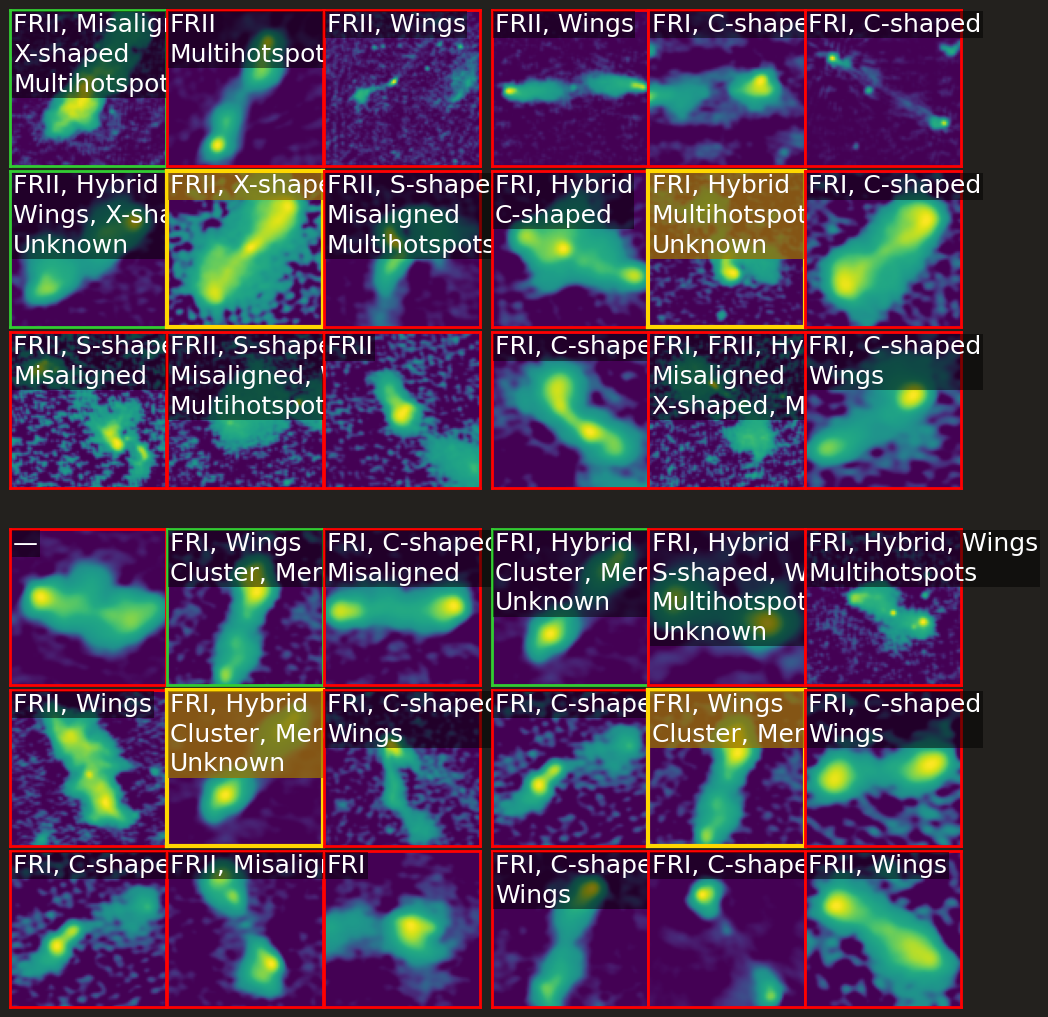

In [9]:
if 'images_all' not in vars():
    images_all = np.load(IMAGES_PATH)
if 'images' not in vars():
    images = images_all[idx_arr]

KNN_SEED  = 42
SEP       = 6 / 89
cell_size = 1.6

_LABEL_DISPLAY = {
    "fri": "FRI", "frii": "FRII", "hybrid": "Hybrid", "spiral": "Spiral",
    "relaxed": "Relaxed", "cshaped": "C-shaped", "sshaped": "S-shaped",
    "misaligned": "Misaligned", "wings": "Wings", "xshaped": "X-shaped",
    "straight": "Straight", "multihotspots": "Multihotspots",
    "continuous": "Continuous", "banding": "Banding", "onesided": "One-sided",
    "restarted": "Restarted", "cluster": "Cluster", "merger": "Merger",
    "diffuse": "Diffuse", "unknown": "Unknown",
}

def _wrap_label(names, max_chars=18):
    lines, cur = [], ''
    for p in names:
        cand = f'{cur}, {p}' if cur else p
        if len(cand) > max_chars and cur:
            lines.append(cur); cur = p
        else:
            cur = cand
    if cur: lines.append(cur)
    return '\n'.join(lines)

rng_knn  = np.random.default_rng(KNN_SEED)
nn_model = NearestNeighbors(n_neighbors=9, metric='euclidean').fit(projections)

# One random query per SCORE_4 class
queries = []
for cls in SCORE_4:
    candidates = np.where(labels_npy_df[cls].values)[0]
    if len(candidates) == 0:
        continue
    idx = rng_knn.choice(candidates)
    queries.append((cls, idx))

N_CLASSES = len(queries)
N_TOP     = (N_CLASSES + 1) // 2   # galleries in top row
N_BOT     = N_CLASSES - N_TOP       # galleries in bottom row

# Width ratios: each gallery = 3 image columns, separated by 1 narrow SEP column
top_ratios = []
for _i in range(N_TOP):
    top_ratios += [1, 1, 1]
    if _i < N_TOP - 1:
        top_ratios.append(SEP)

_top_total = N_TOP * 3 + (N_TOP - 1) * SEP
_bot_used  = N_BOT * 3 + (N_BOT - 1) * SEP

if N_BOT == N_TOP:
    # Symmetric layout — no pad columns needed
    bot_ratios    = list(top_ratios)
    bot_col_start = 0
else:
    _pad = (_top_total - _bot_used) / 2
    bot_ratios = [_pad]
    for _i in range(N_BOT):
        bot_ratios += [1, 1, 1]
        if _i < N_BOT - 1:
            bot_ratios.append(SEP)
    bot_ratios.append(_pad)
    bot_col_start = 1

fig_width  = _top_total * cell_size
fig_height = (3 * cell_size + 0.2) * 2 + 0.3
fig = plt.figure(figsize=(fig_width, fig_height))
fig.patch.set_facecolor('#23211E')

gs_outer = GridSpec(2, 1, figure=fig, hspace=0.08)
fig.subplots_adjust(top=0.99, bottom=0.02, left=0.01, right=0.99)
gs_top = gs_outer[0].subgridspec(3, len(top_ratios), wspace=0.005, hspace=0.02,
                                  width_ratios=top_ratios)
gs_bot = gs_outer[1].subgridspec(3, len(bot_ratios), wspace=0.005, hspace=0.02,
                                  width_ratios=bot_ratios)

sel_idxs       = np.array([idx for _, idx in queries])
_, knn_indices = nn_model.kneighbors(projections[sel_idxs])

def _fill_gallery(gs_row, col_offset, q_idx, nn_idxs, query_cls):
    neighbours = [i for i in nn_idxs if i != q_idx][:8]
    grid = [neighbours[0], neighbours[1], neighbours[2],
            neighbours[3], None,          neighbours[4],
            neighbours[5], neighbours[6], neighbours[7]]
    q_img = images[q_idx]
    if q_img.ndim == 3:
        q_img = q_img[0]
    for flat_pos, real_idx in enumerate(grid):
        r  = flat_pos // 3
        c  = col_offset + (flat_pos % 3)
        ax = fig.add_subplot(gs_row[r, c])
        if real_idx is None:
            # Query image — gold border
            ax.imshow(q_img, cmap='viridis', origin='lower')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            q_active = [_LABEL_DISPLAY.get(col, col) for col in LABEL_COLS if labels_npy_df.iloc[q_idx][col]]
            ax.text(0.02, 0.98, _wrap_label(q_active),
                    transform=ax.transAxes, fontsize=18, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='#9a7200', alpha=0.75, pad=1, linewidth=0))
        else:
            nb_img = images[real_idx]
            if nb_img.ndim == 3:
                nb_img = nb_img[0]
            ax.imshow(nb_img, cmap='viridis', origin='lower')
            nb_active = [_LABEL_DISPLAY.get(col, col) for col in LABEL_COLS if labels_npy_df.iloc[real_idx][col]]
            border_color = 'limegreen' if query_cls in [col for col in LABEL_COLS if labels_npy_df.iloc[real_idx][col]] else 'red'
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2)
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.98, _wrap_label(nb_active) if nb_active else '—',
                    transform=ax.transAxes, fontsize=18, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

for _gal_i, ((cls, q_idx), knn_row) in enumerate(zip(queries[:N_TOP], knn_indices[:N_TOP])):
    _fill_gallery(gs_top, _gal_i * 4, q_idx, knn_row, cls)

for _gal_i, ((cls, q_idx), knn_row) in enumerate(zip(queries[N_TOP:], knn_indices[N_TOP:])):
    _fill_gallery(gs_bot, bot_col_start + _gal_i * 4, q_idx, knn_row, cls)

_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "knn_gallery.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
_pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
_pdf_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_pdf_dir / "knn_gallery.pdf", bbox_inches="tight")

plt.show()

### 2.5 nDCG@10 Per-Class Retrieval Quality

`nDCGk_avg_fast` computes the mean nDCG@10 score for a given morphological class by treating every member of that class as a query in turn, ranking the remaining embeddings by cosine similarity, and scoring the ranked list against ground-truth labels. A score of 1.0 means all top-10 nearest neighbours belong to the correct class; 0.0 means none do.

Loads test embeddings from the diagonal seed dirs of the configured run (`_run_dir`), computes per-class nDCG@10 for each seed, and collects results into `run_results` for downstream plotting.

In [10]:
def get_relevance(proj_in, lab_in, ref_class, mode="uniform"):
    relevance = np.zeros((proj_in.shape[0],))
    relevance[lab_in[:,ref_class]==True] = 1
    return relevance

def DCG(relevance_descending, k=10):
    num = 2**relevance_descending[:k] - 1
    den = np.log2(1+np.arange(1,k+1))
    return (num/den).sum()

def nDCG(relevance, sorting_cossim, k=10):
    IDCGk = DCG(np.sort(relevance)[::-1], k=k)
    DCGk = DCG(relevance[sorting_cossim], k=k)
    return DCGk/IDCGk

def nDCGk_avg(proj_in, lab_in, ref_class, k=20):
    mask_class = (lab_in[:,ref_class]==True)
    res = []
    for idx_ref in range(mask_class.sum()):
        reference_proj = proj_in[(lab_in[:,ref_class]==True)][idx_ref]
        mask_ref = (np.arange(proj_in.shape[0])==np.argwhere((lab_in[:,ref_class]==True))[idx_ref])
        proj_search = proj_in[~mask_ref]
        cos_d  = cdist(reference_proj[None,:], proj_search,   metric='cosine')
        sorting_cossim = np.argsort(cos_d.squeeze())
        relevance = get_relevance(proj_search, lab_in[~mask_ref], ref_class)
        nDCG_samp = nDCG(relevance, sorting_cossim, k=k)
        res.append(nDCG_samp)
    return (np.asarray(res).mean())

def nDCGk_avg_fast(proj_norm, lab_in, ref_class, k=20):
    """Vectorized nDCG@k. proj_norm must be L2-normalised (call once per run).
    Computes all query similarities in a single matrix multiply instead of
    one cdist call per class member."""
    mask      = lab_in[:, ref_class].astype(bool)
    class_idx = np.where(mask)[0]
    n_class   = len(class_idx)
    if n_class == 0:
        return np.nan

    # (n_class, N) cosine similarity via matmul; exclude self
    sim = proj_norm[class_idx] @ proj_norm.T          # (n_class, N)
    sim[np.arange(n_class), class_idx] = -np.inf

    # Relevance in ranked order for each query
    order      = np.argsort(-sim, axis=1)             # (n_class, N)
    rel_ranked = mask[order][:, :k].astype(float)     # (n_class, k)

    # DCG per query
    discount = 1.0 / np.log2(np.arange(2, k + 2))    # rank 1..k
    dcg      = (rel_ranked * discount).sum(axis=1)    # (n_class,)

    # IDCG is the same for every query: min(k, n_class-1) hits at top ranks
    n_rel = min(k, n_class - 1)
    idcg  = discount[:n_rel].sum() if n_rel > 0 else 0.0

    if idcg == 0:
        return 0.0
    return float((dcg / idcg).mean())

In [11]:
# Use CV fold dirs (5-fold CV on data_seed=2); fall back to diagonal seed dirs
run_dirs = _get_cv_fold_dirs(_run_dir) or _get_diagonal_seed_dirs(_run_dir)
print(f"Found {len(run_dirs)} run dir(s) in {_run_dir.name}.")

def _ndcg_data_seed(rd):
    ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    return int(ckpt["config"]["data_seed"])

run_results = []
for rd in run_dirs:
    # Family name is 3 levels up for CV folds (.../family/data_seed_2/training_seed_2/cross_val_K)
    # and 2 levels up for diagonal seeds (.../family/data_seed_N/training_seed_N)
    _name_for_regex = (rd.parent.parent.parent.name if rd.name.startswith("cross_val")
                       else rd.parent.parent.name)
    m = re.search(r'_sw([\d.]+)_f([\d.]+)', _name_for_regex)
    if not m:
        continue
    sw_val = float(m.group(1))
    f_val  = float(m.group(2))

    byol_dir  = rd / "data" / "byol"
    proj_path = byol_dir / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        # fallback for old runs
        proj_path = rd / "data" / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        print(f"  skipping {rd.name}  (missing {EVAL_SPLIT} projections)")
        continue

    # Labels: use fold-specific splits dir for CV folds, seed-level for diagonal
    try:
        _ds = _ndcg_data_seed(rd)
    except Exception:
        _ds = 42
    if rd.name.startswith("cross_val"):
        _fold_sdir = OUTPUTS_ROOT / "data_splits" / str(_ds) / rd.name
    else:
        _fold_sdir = OUTPUTS_ROOT / "data_splits" / str(_ds)
    labels_path = _fold_sdir / f"{EVAL_SPLIT}_labels.npy"
    if not labels_path.exists():
        print(f"  skipping {rd.name}  (missing labels at {labels_path})")
        continue

    proj   = np.load(proj_path)
    labels = np.load(labels_path)

    # Old runs saved projections for ALL sources in dataset order.
    # Subset to the test split using test_idx if shapes don't match.
    if proj.shape[0] != labels.shape[0]:
        test_idx_path = _fold_sdir / "test_idx.npy"
        if not test_idx_path.exists():
            print(f"  skipping {rd.name}  (shape mismatch proj={proj.shape} labels={labels.shape}, no test_idx.npy)")
            continue
        test_idx = np.load(test_idx_path)
        proj = proj[test_idx]
    if proj.shape[0] != labels.shape[0]:
        print(f"  skipping {rd.name}  (shape mismatch after subsetting: proj={proj.shape} labels={labels.shape})")
        continue

    # L2-normalise once; nDCGk_avg_fast uses a single matmul per class
    norms     = np.linalg.norm(proj, axis=1, keepdims=True)
    proj_norm = proj / np.maximum(norms, 1e-10)
    ndcg = [nDCGk_avg_fast(proj_norm, labels, c, k=NDCG_K) for c in range(labels.shape[1])]
    run_results.append(dict(name=_name_for_regex, f=f_val, sw=sw_val, ndcg=ndcg))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})")

print(f"\nLoaded {len(run_results)} runs.")


Found 5 run dir(s) in pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1.


  loaded cross_val_0  (f=1.0, sw=0.05)


  loaded cross_val_1  (f=1.0, sw=0.05)


  loaded cross_val_2  (f=1.0, sw=0.05)


  loaded cross_val_3  (f=1.0, sw=0.05)


  loaded cross_val_4  (f=1.0, sw=0.05)

Loaded 5 runs.


### 2.6 Ellipses IsoForest Baseline

Fits `EllipseFitFeatures` (6 percentiles × 5 ellipse parameters → 30 features) on all images and scores them with `IsolationForest`. Results are cached per `data_seed` in `outputs/anomaly_baselines/baselines_{seed}.json` and used as the unsupervised baseline in the recall-curve plots.

In [12]:
# ── Compute / load baselines (ellipses) on the test set ────────────────────────
# Ellipses IsoForest is fitted on ALL images (unsupervised, no split needed).
# Results are keyed by data_seed and hash-validated against test_idx.npy.

# Use _data_seed_ and _splits_dir_ already derived in cell 15
_data_seed = _data_seed_

# test_idx.npy: already resolved in cell 15 via _splits_dir_
_test_idx_path = _splits_dir_ / "test_idx.npy"
if not _test_idx_path.exists():
    _test_idx_path = Path(RUN_DIR) / "test_idx.npy"
_hash = hashlib.sha256(open(_test_idx_path, "rb").read()).hexdigest()
(OUTPUTS_ROOT / "anomaly_baselines").mkdir(parents=True, exist_ok=True)
_baselines_path = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{_data_seed}.json"


# ── Load ellipse features (cache from _ell_cache_{seed}/) ─────────────────────
_ell_outdir  = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_cache_{_data_seed}"
_ell_outdir.mkdir(exist_ok=True)
_ell_parquet = _ell_outdir / "EllipseFitFeatures_output.parquet"

if _ell_parquet.exists():
    _all_ell = pd.read_parquet(_ell_parquet)
    print(f"Loaded ellipse features from cache ({len(_all_ell)} sources, {_ell_parquet.name})")
else:
    print("Extracting ellipse features (first run — will cache) …")
    _images_all = np.load(IMAGES_PATH).astype(np.float32) / 255.0

    class _NumpyImageDataset(_AstroDataset):
        def __init__(self, images, output_dir, **kwargs):
            super().__init__(output_dir=output_dir, **kwargs)
            self.images   = images
            self.index    = [str(i) for i in range(len(images))]
            self.metadata = pd.DataFrame(index=self.index)
        def get_sample(self, idx):       return self.images[int(idx)]
        def get_display_data(self, idx): return {}

    _ds  = _NumpyImageDataset(_images_all, output_dir=str(_ell_outdir), force_rerun=False)
    # upper_limit=150: raised from the library default of 100 to allow the built-in
    # upscaling retry inside EllipseFitFeatures for sources whose innermost ellipse
    # contour has <5 points, rescuing many sources that previously produced all-NaN
    # feature vectors.
    _ext = _sf.EllipseFitFeatures(percentiles=[90, 80, 70, 60, 50, 0], channel=0,
                                   output_dir=str(_ell_outdir), force_rerun=False,
                                   upper_limit=150)
    _all_ell = _ext.run_on_dataset(_ds)
    del _images_all

# ── NaN count diagnostic ──────────────────────────────────────────────────────
_ell_nan_mask = _all_ell.isna().any(axis=1)
_n_ell_nan    = int(_ell_nan_mask.sum())
_n_ell_total  = len(_all_ell)
_n_prev_nan   = round(0.185 * _n_ell_total)
_n_rescued    = max(0, _n_prev_nan - _n_ell_nan)
print(f"EllipseFit NaN rows — historical (upper_limit=100): ~{_n_prev_nan}/{_n_ell_total}"
      f" ({100 * _n_prev_nan / _n_ell_total:.1f}%)")
print(f"EllipseFit NaN rows — current   (upper_limit=150):  {_n_ell_nan}/{_n_ell_total}"
      f" ({100 * _n_ell_nan / _n_ell_total:.1f}%)")
print(f"Sources rescued by higher upper_limit: ~{_n_rescued}"
      f"  ({100 * _n_rescued / _n_ell_total:.1f}% of dataset)")

# ── IsoForest fit: median imputation instead of dropping NaN rows ─────────────
_ell_col_medians = _all_ell[~_ell_nan_mask].median()
_all_ell_imp     = _all_ell.copy()
_all_ell_imp[_ell_nan_mask] = _all_ell_imp[_ell_nan_mask].fillna(_ell_col_medians)
_n_imp_iso = int(_ell_nan_mask.sum())
print(f"IsoForest imputation: {_n_imp_iso} NaN rows filled with column medians "
      f"(all {_n_ell_total} sources scored)")

baselines = None
if _baselines_path.exists():
    with open(_baselines_path) as _fh:
        _cached = json.load(_fh)
    if _cached.get("test_idx_hash") == _hash:
        baselines = _cached
        print(f"Loaded baselines from cache  (seed={_data_seed}, n_eval={baselines['n_eval']})")
        # Invalidate cached ellipses_gp if it was computed on a smaller test set
        _eg = baselines.get("ellipses_gp")
        if _eg and _eg.get("x") and len(_eg["x"]) != baselines["n_eval"]:
            print(f"  Invalidating cached ellipses_gp (n={len(_eg['x'])} ≠ n_eval={baselines['n_eval']})")
            baselines["ellipses_gp"] = None

if baselines is None:
    print(f"Computing baselines (seed={_data_seed}) ...")
    _n_eval = len(_test_idx)
    _x      = np.arange(1, _n_eval + 1)
    _n_pos  = int((_test_human >= POSITIVE_THRESHOLD).sum())

    baselines = {
        "test_idx_hash": _hash, "data_seed": _data_seed,
        "n_eval": _n_eval, "n_pos": _n_pos,
    }
    with open(_baselines_path, "w") as _fh:
        json.dump(baselines, _fh)
    print(f"Saved to {_baselines_path}")

# ── Ellipses GP — IsoForest + Protege GP (computed inline) ───────────────────
_ell_gp = baselines.get("ellipses_gp") if baselines else None

if _ell_gp is None:
    print("Computing Ellipses GP baseline ...")
    _iforest = _IsoForest(n_estimators=200, random_state=_data_seed)
    _iforest.fit(_all_ell_imp.values)
    try:
        _tr_ell = _all_ell_imp.iloc[idx_arr].copy();   _tr_ell.index = source_names
        _te_ell = _all_ell_imp.iloc[_test_idx].copy(); _te_ell.index = _test_names

        # ── GP block: median imputation on train/test subsets ─────────────────
        _tr_ell_nan = _tr_ell.isna().any(axis=1)
        _te_ell_nan = _te_ell.isna().any(axis=1)
        _n_tr_imp_gp = int(_tr_ell_nan.sum())
        _n_te_imp_gp = int(_te_ell_nan.sum())
        if _n_tr_imp_gp > 0 or _n_te_imp_gp > 0:
            _tr_med_gp = _tr_ell[~_tr_ell_nan].median()
            _tr_ell    = _tr_ell.fillna(_tr_med_gp)
            _te_ell    = _te_ell.fillna(_tr_med_gp)
        print(f"  GP block imputation: {_n_tr_imp_gp} train + {_n_te_imp_gp} test NaN rows "
              f"filled  ({len(_tr_ell)} train, {len(_te_ell)} test sources, none dropped)")

        # IsoForest scores → normalize to [0.1, 5]
        _tr_iso  = _iforest.decision_function(_tr_ell.values)
        _te_iso  = _iforest.decision_function(_te_ell.values)
        _iso_all = -np.concatenate([_tr_iso, _te_iso])
        _iso_rng = _iso_all.max() - _iso_all.min()
        _iso_norm    = 0.1 + (5 - 0.1) * (_iso_all - _iso_all.min()) / (_iso_rng + 1e-9)
        _tr_iso_norm = _iso_norm[:len(_tr_iso)]
        _te_iso_norm = _iso_norm[len(_tr_iso):]

        _tr_human_gp = labels_df.loc[_tr_ell.index, "human_label"].values.astype(float)

        _scaler_ell  = StandardScaler()
        _tr_scaled   = _scaler_ell.fit_transform(_tr_ell.values)
        _te_scaled   = _scaler_ell.transform(_te_ell.values)
        _cols        = [f"f{i}" for i in range(_tr_scaled.shape[1])]
        _tr_feat     = pd.DataFrame(_tr_scaled, index=_tr_ell.index, columns=_cols)
        _te_feat     = pd.DataFrame(_te_scaled, index=_te_ell.index, columns=_cols)
        _all_feat_gp = pd.concat([_tr_feat, _te_feat])

        _scores_gp = pd.DataFrame({
            "score":       np.concatenate([_tr_iso_norm, _te_iso_norm]),
            "human_label": np.concatenate([_tr_human_gp, np.full(len(_te_ell), -1.0)]),
        }, index=_all_feat_gp.index)

        print(f"  Running GP on {len(_tr_ell)} train + {len(_te_ell)} test sources ...")
        _ell_gp_outdir = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_gp_cache_{_data_seed}"
        _ell_gp_outdir.mkdir(exist_ok=True)
        _ell_gp_pipeline = protege.GaussianProcess(
            _all_feat_gp, force_rerun=True,
            output_dir=str(_ell_gp_outdir),
            ei_tradeoff=EPSILON,
        )
        _fwl    = _ell_gp_pipeline.combine_data_frames(_all_feat_gp, _scores_gp)
        _gp_out = _ell_gp_pipeline.run(_fwl)

        _te_scored = _gp_out.loc[_te_ell.index, "trained_score"].sort_values(ascending=False)
        _te_tl     = pd.Series(_test_human, index=_test_names).loc[_te_scored.index]
        _n_pos_all = int((_test_human >= POSITIVE_THRESHOLD).sum())
        _cum_gp    = np.cumsum((_te_tl >= POSITIVE_THRESHOLD).astype(int).values)
        _x_gp      = np.arange(1, len(_cum_gp) + 1)
        _auc_gp    = (float(np.trapezoid(_cum_gp, _x_gp) / (len(_cum_gp) * _n_pos_all))
                      if _n_pos_all > 0 else 0.0)
        _ell_gp = {"recall": _cum_gp.tolist(), "x": _x_gp.tolist(), "auc": _auc_gp}
        print(f"  Ellipses GP AUC={_auc_gp:.4f}  (n_eval={len(_cum_gp)}, n_pos={_n_pos_all})")
    except Exception as _e:
        print(f"  Ellipses GP failed: {_e}")
        traceback.print_exc()

baselines["ellipses_gp"] = _ell_gp
with open(_baselines_path, "w") as _fh:
    json.dump(baselines, _fh)
if _ell_gp is not None:
    print(f"Baselines (incl. Ellipses GP AUC={_ell_gp['auc']:.4f}) saved to {_baselines_path}")
else:
    print(f"Baselines saved to {_baselines_path}  (Ellipses GP: not available)")

# ── blob_doh complexity baseline ──────────────────────────────────────────────
_DOH_PARAMS = {"min_sigma": 1.0, "max_sigma": 15, "num_sigma": 10, "threshold": 0.005}
_bl_complexity = baselines.get("complexity")
_needs_doh = (_bl_complexity is None
              or _bl_complexity.get("method") != "blob_doh"
              or _bl_complexity.get("params") != _DOH_PARAMS)

if not _needs_doh:
    print(f"blob_doh complexity loaded from cache (AUC={_bl_complexity['auc']:.4f})")
else:
    print("Computing blob_doh complexity baseline on test set …")
    def _run_doh(img_f32):
        lo, hi = img_f32.min(), img_f32.max()
        img_norm = (img_f32 - lo) / (hi - lo) if hi > lo else np.zeros_like(img_f32)
        return float(len(_blob_doh(img_norm, **_DOH_PARAMS)))

    _doh_imgs   = np.load(IMAGES_PATH, mmap_mode="r")[_test_idx].astype(np.float32)
    _doh_scores = np.array([_run_doh(_doh_imgs[i]) for i in range(len(_doh_imgs))],
                           dtype=float)
    del _doh_imgs

    _doh_order  = np.argsort(_doh_scores)[::-1]
    _doh_binary = (_test_human[_doh_order] >= POSITIVE_THRESHOLD).astype(int)
    _doh_cum    = np.cumsum(_doh_binary)
    _doh_x      = np.arange(1, len(_doh_cum) + 1)
    _doh_n_pos  = int(_doh_binary.sum())
    _doh_auc    = (float(np.trapezoid(_doh_cum, _doh_x) / (len(_doh_cum) * _doh_n_pos))
                   if _doh_n_pos > 0 else 0.0)

    baselines["complexity"] = {
        "recall": _doh_cum.tolist(),
        "x":      _doh_x.tolist(),
        "auc":    _doh_auc,
        "method": "blob_doh",
        "params": _DOH_PARAMS,
    }
    with open(_baselines_path, "w") as _fh:
        json.dump(baselines, _fh)
    print(f"blob_doh complexity AUC={_doh_auc:.4f}  saved → {_baselines_path.name}")

Loaded ellipse features from cache (7596 sources, EllipseFitFeatures_output.parquet)
EllipseFit NaN rows — historical (upper_limit=100): ~1405/7596 (18.5%)
EllipseFit NaN rows — current   (upper_limit=150):  207/7596 (2.7%)
Sources rescued by higher upper_limit: ~1198  (15.8% of dataset)
IsoForest imputation: 207 NaN rows filled with column medians (all 7596 sources scored)
Loaded baselines from cache  (seed=2, n_eval=1520)
Baselines (incl. Ellipses GP AUC=0.5615) saved to /users/mbredber/p3_SUPLAT/outputs/anomaly_baselines/baselines_2.json
blob_doh complexity loaded from cache (AUC=0.5760)


### 2.7 nDCG by Interest Tier × Feature Space

Compares retrieval quality (nDCG@10) across interest tiers for three feature spaces: BYOL projections, Ellipse-fit features (30-D), and blob-DoH complexity (1-D). Error bars for all methods show the 16th–84th percentile range across diagonal seeds (data_seed_N / training_seed_N), giving a consistent cross-split uncertainty estimate.

Requires §2.6 (`_all_ell_imp`) to have been run first.

DoH all-image cache: _doh_all_2.npy  (7596 sources)
  sw=0: no family dir found (pattern: *_sw0_f1)
  sw=0.05: pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  → 5 CV folds
  sw=0.1: pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1  → 5 CV folds
  sw=0.5: pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  → 1 diagonal seeds (no CV)

2  n_test=2279  positives=404


  BYOL sw=0.5: ['0.541', '0.551', '0.207', '0.171']


  Ellipses: ['0.372', '0.460', '0.129', '0.067']
  DoH:      ['0.414', '0.518', '0.103', '0.120']

cross_val_0  n_test=1520  positives=263
  BYOL sw=0.05: ['0.516', '0.550', '0.177', '0.117']


  BYOL sw=0.1: ['0.512', '0.555', '0.188', '0.112']
  Ellipses: ['0.368', '0.465', '0.133', '0.070']
  DoH:      ['0.405', '0.443', '0.171', '0.025']

cross_val_1  n_test=1519  positives=262


  BYOL sw=0.05: ['0.577', '0.547', '0.218', '0.184']
  BYOL sw=0.1: ['0.571', '0.542', '0.220', '0.185']
  Ellipses: ['0.398', '0.483', '0.144', '0.073']


...

  BYOL sw=0.05: ['0.574', '0.557', '0.205', '0.132']
  BYOL sw=0.1: ['0.557', '0.565', '0.222', '0.124']


  Ellipses: ['0.392', '0.461', '0.137', '0.059']
  DoH:      ['0.545', '0.344', '0.184', '0.053']

cross_val_3  n_test=1519  positives=270
  BYOL sw=0.05: ['0.559', '0.542', '0.240', '0.068']


  BYOL sw=0.1: ['0.567', '0.542', '0.228', '0.094']
  Ellipses: ['0.392', '0.437', '0.149', '0.037']
  DoH:      ['0.452', '0.436', '0.183', '0.031']

cross_val_4  n_test=1519  positives=250


  BYOL sw=0.05: ['0.541', '0.580', '0.188', '0.071']
  BYOL sw=0.1: ['0.541', '0.577', '0.189', '0.075']


  Ellipses: ['0.359', '0.487', '0.140', '0.047']
  DoH:      ['0.449', '0.514', '0.097', '0.032']

Summary nDCG@10 per tier:
  BYOL sw=0: no runs found
  BYOL sw=0.05 (5 fold(s)): ['0.553', '0.555', '0.206', '0.114']
  BYOL sw=0.1 (5 fold(s)): ['0.550', '0.556', '0.209', '0.118']
  BYOL sw=0.5 (1 fold(s)): ['0.541', '0.551', '0.207', '0.171']
  Ellipses (6 fold(s)): ['0.380', '0.466', '0.139', '0.059']
  DoH      (6 fold(s)): ['0.452', '0.454', '0.150', '0.055']


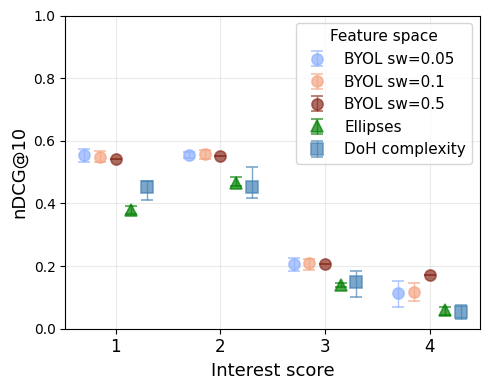

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/protege/nn_ndcg10_by_tier.png

Macro-avg nDCG@10 over tiers (68% CI):
  BYOL sw=0.05                    0.357  +0.022 / -0.024
  BYOL sw=0.1                     0.358  +0.019 / -0.021
  BYOL sw=0.5                     0.367  +0.000 / -0.000
  Ellipses                        0.261  +0.012 / -0.011
  DoH complexity                  0.278  +0.034 / -0.037


In [13]:
# ── nDCG@10 by query interest tier × feature space ───────────────────────────
# For each test source with interest score s, ranks all other sources by
# similarity and computes nDCG@10 treating sources with the same score as
# relevant. Averaged over all queries in tier s.
#
# Error bars come from the 5 CV folds (each with a different test split).
# Each sw value is loaded independently from BYOL_RUNS_ROOT.

_BYOL_F     = 1.0
_SW_VALUES  = [0.0, 0.05, 0.1, 0.5]
_sw_cividis = {0.0: '#1B2A6B', 0.05: '#8DB0FE', 0.1: '#F4A582', 0.5: '#8B2E1F'}

# DoH scores are image-level and split-independent — use whichever cache exists
_doh_all_cache = None
for _doh_p in sorted((OUTPUTS_ROOT / "anomaly_baselines").glob("_doh_all_*.npy")):
    _doh_all_cache = np.load(_doh_p).astype(np.float32)
    print(f"DoH all-image cache: {_doh_p.name}  ({len(_doh_all_cache)} sources)")
    break

def _make_test_human(test_idx):
    """Build interest-score array for a given test_idx using the global labels_all."""
    _ldf = pd.DataFrame(labels_all[test_idx].astype(bool), columns=LABEL_COLS)
    _hl  = np.ones(len(_ldf), dtype=int)
    for _sv, _cols in reversed(TIERS):
        _hl[_ldf[_cols].any(axis=1).values] = _sv
    return _hl

# ── nDCG helpers ──────────────────────────────────────────────────────────────
_NDCG_K = 10

def _ndcg_by_tier(proj_norm, human_scores, tiers, k=_NDCG_K):
    """nDCG@k per interest tier via cosine similarity on L2-normalised embeddings."""
    sim = proj_norm @ proj_norm.T
    np.fill_diagonal(sim, -np.inf)
    discount = 1.0 / np.log2(np.arange(2, k + 2))
    result = []
    for s in tiers:
        qi    = np.where(human_scores == s)[0]
        rel   = (human_scores == s).astype(float)
        n_rel = max(0, int(rel.sum()) - 1)
        idcg  = discount[:min(k, n_rel)].sum() if n_rel > 0 else 0.0
        if idcg == 0 or len(qi) == 0:
            result.append(np.nan)
            continue
        order      = np.argsort(-sim[qi], axis=1)
        rel_ranked = rel[order][:, :k]
        dcg        = (rel_ranked * discount).sum(axis=1)
        result.append(float((dcg / idcg).mean()))
    return np.array(result)

def _ndcg_by_tier_scalar(scores_1d, human_scores, tiers, k=_NDCG_K):
    """nDCG@k per interest tier via scalar proximity (for 1-D scores like DoH)."""
    discount = 1.0 / np.log2(np.arange(2, k + 2))
    result = []
    for s in tiers:
        qi    = np.where(human_scores == s)[0]
        rel   = (human_scores == s).astype(float)
        n_rel = max(0, int(rel.sum()) - 1)
        idcg  = discount[:min(k, n_rel)].sum() if n_rel > 0 else 0.0
        if idcg == 0 or len(qi) == 0:
            result.append(np.nan)
            continue
        dcgs = []
        for q in qi:
            dists    = np.abs(scores_1d[q] - scores_1d)
            dists[q] = np.inf
            order    = np.argsort(dists)[:k]
            dcgs.append(float((rel[order] * discount[:len(order)]).sum()))
        result.append(np.mean(dcgs) / idcg)
    return np.array(result)

# ── Build sw → fold_dirs map by scanning BYOL_RUNS_ROOT ──────────────────────
# Each sw value has its own family dir; we load CV folds (or diagonal seeds)
# independently so all sw values get data regardless of which run is "selected".
_sw_fold_dirs = {}   # sw → list of (fold_dir, fold_splits_dir) tuples
for _sw in _SW_VALUES:
    _sw_str     = str(int(_sw)) if _sw == int(_sw) else str(_sw)
    _sw_pattern = f"*_sw{_sw_str}_f{int(_BYOL_F) if _BYOL_F == int(_BYOL_F) else _BYOL_F}"
    _candidates = sorted(BYOL_RUNS_ROOT.glob(_sw_pattern))
    if not _candidates:
        print(f"  sw={_sw:g}: no family dir found (pattern: {_sw_pattern})")
        continue
    _fam = _candidates[-1]  # latest matching family
    _cv  = _get_cv_fold_dirs(_fam)
    if _cv:
        _sw_fold_dirs[_sw] = [(_fd, _cv_splits_dir(_fd)) for _fd in _cv]
        print(f"  sw={_sw:g}: {_fam.name}  → {len(_cv)} CV folds")
    else:
        _diag = _get_diagonal_seed_dirs(_fam)
        _sw_fold_dirs[_sw] = [(_fd, OUTPUTS_ROOT / "data_splits" / str(
            int(_fd.parent.name.split("_")[-1]))) for _fd in _diag]
        print(f"  sw={_sw:g}: {_fam.name}  → {len(_diag)} diagonal seeds (no CV)")

# ── Collect all unique (splits_dir) to iterate once per split ─────────────────
# All sw values share the same folds → same test splits → dedup by splits_dir path.
_unique_splits = []
_seen_splits   = set()
for _sw, _pairs in _sw_fold_dirs.items():
    for _fd, _sd in _pairs:
        if str(_sd) not in _seen_splits:
            _unique_splits.append(_sd)
            _seen_splits.add(str(_sd))
_unique_splits.sort(key=str)

# ── Per-fold nDCG computation ─────────────────────────────────────────────────
_tiers = [1, 2, 3, 4]
_byol_tier_seedrows = {sw: [] for sw in _SW_VALUES}
_ell_tier_seedrows  = []
_doh_tier_seedrows  = []

for _sp in _unique_splits:
    _test_idx_ds   = np.load(_sp / "test_idx.npy")
    _test_human_ds = _make_test_human(_test_idx_ds)
    _n_pos_ds      = int((_test_human_ds >= POSITIVE_THRESHOLD).sum())
    print(f"\n{_sp.name}  n_test={len(_test_idx_ds)}  positives={_n_pos_ds}")

    # BYOL nDCG for each sw value whose fold matches this splits_dir
    for _sw, _pairs in _sw_fold_dirs.items():
        _fd_match = next((_fd for _fd, _sd in _pairs if str(_sd) == str(_sp)), None)
        if _fd_match is None:
            continue
        _bd = _fd_match / "data" / "byol" if (_fd_match / "data" / "byol").exists() else _fd_match / "data"
        _pp = _bd / f"test_{_feat_suffix}.npy"
        if not _pp.exists():
            print(f"  sw={_sw:g}: projections not found, skipping")
            continue
        _p = np.load(_pp).astype(np.float32)[:len(_test_human_ds)]
        _p = _p / np.maximum(np.linalg.norm(_p, axis=1, keepdims=True), 1e-10)
        _row = _ndcg_by_tier(_p, _test_human_ds, _tiers)
        _byol_tier_seedrows[_sw].append(_row)
        print(f"  BYOL sw={_sw:g}: {[f'{v:.3f}' for v in _row]}")

    # Ellipses nDCG (once per unique split)
    _ell_te      = _all_ell_imp.iloc[_test_idx_ds].values.astype(np.float32)
    _ell_te_norm = _ell_te / np.maximum(np.linalg.norm(_ell_te, axis=1, keepdims=True), 1e-10)
    _ell_row = _ndcg_by_tier(_ell_te_norm, _test_human_ds, _tiers)
    _ell_tier_seedrows.append(_ell_row)
    print(f"  Ellipses: {[f'{v:.3f}' for v in _ell_row]}")

    # DoH nDCG — image-level scores, split-independent
    _doh_src = _doh_all_cache
    if _doh_src is None:
        _ds_from_sp = _sp.parent.name if _sp.name.startswith("cross_val") else _sp.name
        _dc = OUTPUTS_ROOT / "anomaly_baselines" / f"_doh_all_{_ds_from_sp}.npy"
        _doh_src = np.load(_dc).astype(np.float32) if _dc.exists() else None
    if _doh_src is not None:
        _doh_row = _ndcg_by_tier_scalar(_doh_src[_test_idx_ds], _test_human_ds, _tiers)
        _doh_tier_seedrows.append(_doh_row)
        print(f"  DoH:      {[f'{v:.3f}' for v in _doh_row]}")
    else:
        print(f"  DoH: no cache found for {_sp.name}, skipping")

# ── Aggregate across folds: mean / 16th / 84th percentile ─────────────────────
def _tier_ci(seed_rows):
    arr = np.array(seed_rows, dtype=float)
    return (np.nanmean(arr, axis=0),
            np.nanpercentile(arr, 16, axis=0),
            np.nanpercentile(arr, 84, axis=0))

_byol_sw_stats = {}
print(f"\nSummary nDCG@{_NDCG_K} per tier:")
for _sw in _SW_VALUES:
    _rows = _byol_tier_seedrows[_sw]
    if not _rows:
        print(f"  BYOL sw={_sw:g}: no runs found")
        continue
    _mn, _lo, _hi = _tier_ci(_rows)
    _byol_sw_stats[_sw] = (_mn, _lo, _hi, len(_rows))
    print(f"  BYOL sw={_sw:g} ({len(_rows)} fold(s)): {[f'{v:.3f}' for v in _mn]}")

_ell_tier_stats = _tier_ci(_ell_tier_seedrows) if _ell_tier_seedrows else None
_doh_tier_stats = _tier_ci(_doh_tier_seedrows) if _doh_tier_seedrows else None
if _ell_tier_stats:
    print(f"  Ellipses ({len(_ell_tier_seedrows)} fold(s)): {[f'{v:.3f}' for v in _ell_tier_stats[0]]}")
if _doh_tier_stats:
    print(f"  DoH      ({len(_doh_tier_seedrows)} fold(s)): {[f'{v:.3f}' for v in _doh_tier_stats[0]]}")

# ── Dotplot ───────────────────────────────────────────────────────────────────
_all_methods = []
for _sw in _SW_VALUES:
    if _sw not in _byol_sw_stats:
        continue
    _mn, _lo, _hi, _n = _byol_sw_stats[_sw]
    _all_methods.append((
        f"BYOL sw={_sw:g}",
        "o", _mn, np.array([_mn - _lo, _hi - _mn]), _sw_cividis[_sw],
    ))

for _stats, _lbl_base, _marker, _color, _n_seeds in [
    (_ell_tier_stats, "Ellipses",       "^", "green",     len(_ell_tier_seedrows)),
    (_doh_tier_stats, "DoH complexity", "s", "steelblue", len(_doh_tier_seedrows)),
]:
    if _stats is None:
        continue
    _mn, _lo, _hi = _stats
    _all_methods.append((
        f"{_lbl_base}",
        _marker, _mn, np.array([_mn - _lo, _hi - _mn]), _color,
    ))

_offsets = np.linspace(-0.30, 0.30, len(_all_methods))

fig_fs, ax_fs = plt.subplots(figsize=(5, 4))
for (label, marker, means, yerr, color), offset in zip(_all_methods, _offsets):
    x_pos = np.array(_tiers, dtype=float) + offset
    ax_fs.errorbar(x_pos, means, yerr=yerr,
                   fmt=marker, color=color, label=label,
                   markersize=8, capsize=4, linewidth=1.2,
                   elinewidth=1.0, markeredgewidth=1.2, alpha=0.7)

ax_fs.set_xticks(_tiers)
ax_fs.set_xticklabels([str(s) for s in _tiers], fontsize=12)
ax_fs.set_xlabel("Interest score", fontsize=13)
ax_fs.set_ylabel(f"nDCG@{_NDCG_K}", fontsize=13)
ax_fs.set_ylim(0, 1)
ax_fs.legend(title="Feature space", fontsize=11, title_fontsize=11, framealpha=0.8)
ax_fs.grid(True, alpha=0.25)
plt.tight_layout()

_out_path = _fig_dir / "nn_ndcg10_by_tier.png"
fig_fs.savefig(_out_path, dpi=150, bbox_inches="tight")
_pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
_pdf_dir.mkdir(parents=True, exist_ok=True)
fig_fs.savefig(_pdf_dir / _out_path.with_suffix(".pdf").name, bbox_inches="tight")
plt.show()
print(f"Saved → {_out_path}")

# ── Summary: macro-avg nDCG ± 68% CI (16th/84th pct across folds) ────────────
print(f"\nMacro-avg nDCG@{_NDCG_K} over tiers (68% CI):")
for label, marker, means, yerr, color in _all_methods:
    _mean_val = np.nanmean(means)
    _lo_w     = np.nanmean(yerr[0])
    _hi_w     = np.nanmean(yerr[1])
    print(f"  {label:30s}  {_mean_val:.3f}  +{_hi_w:.3f} / -{_lo_w:.3f}")


## 3. Interest ranking

Uses the [astronomaly](https://github.com/MichelleLochner/astronomaly) library to run a Gaussian-Process active learner on the learned embeddings. The GP iteratively selects the most informative unlabelled sources via an acquisition function, simulates a human labelling step using ground-truth morphology scores, and updates the model — surfacing rare/interesting sources far more efficiently than random inspection.

The GP is run in **transductive** mode: all sources (train + test) are passed to the GP, but only the training set carries labels during fitting.

### 3.1 PCA Dimensionality importance

Fits a PCA on the combined train+test projections (no prior scaling) and reports how many components explain 95% and 99% of variance.

Embedding dim: 128d  (analysis PCA on first 128 components)
  Dims for 95% variance: 40
  Dims for 99% variance: 56
  Variance captured by 128 components: 1.000


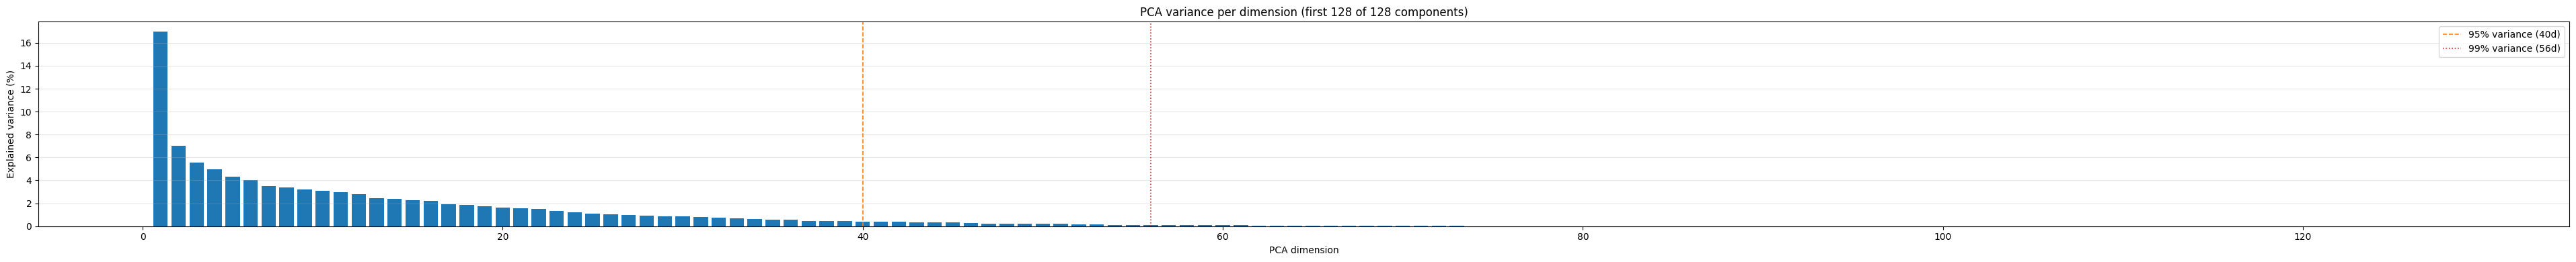

In [14]:
# Always fit a partial PCA for variance analysis (fast: only 128 components)
_n_analysis = min(128, all_proj.shape[1])
_pca_analysis = PCA(n_components=_n_analysis, random_state=42)
_pca_analysis.fit(all_proj)

_cumvar = np.cumsum(_pca_analysis.explained_variance_ratio_)
_n_95   = int(np.searchsorted(_cumvar, 0.95)) + 1 if _cumvar[-1] >= 0.95 else f">{_n_analysis}"
_n_99   = int(np.searchsorted(_cumvar, 0.99)) + 1 if _cumvar[-1] >= 0.99 else f">{_n_analysis}"
print(f"Embedding dim: {all_proj.shape[1]}d  (analysis PCA on first {_n_analysis} components)")
print(f"  Dims for 95% variance: {_n_95}")
print(f"  Dims for 99% variance: {_n_99}")
print(f"  Variance captured by {_n_analysis} components: {_cumvar[-1]:.3f}")

fig, ax = plt.subplots(figsize=(max(6, _n_analysis * 0.3), 4))
ax.bar(np.arange(1, _n_analysis + 1), _pca_analysis.explained_variance_ratio_ * 100, color="tab:blue")
if isinstance(_n_95, int):
    ax.axvline(_n_95, color="tab:orange", linestyle="--", linewidth=1.2, label=f"95% variance ({_n_95}d)")
if isinstance(_n_99, int):
    ax.axvline(_n_99, color="tab:red",    linestyle=":",  linewidth=1.2, label=f"99% variance ({_n_99}d)")
ax.set_xlabel("PCA dimension")
ax.set_ylabel("Explained variance (%)")
ax.set_title(f"PCA variance per dimension (first {_n_analysis} of {all_proj.shape[1]} components)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

_figures_dir = OUTPUTS_ROOT / "figures" / "protege"
_pca_fig_path = _figures_dir / "pca_variance.png"
if FORCE_SAVE_FIGS or not _pca_fig_path.exists():
    _figures_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pca_fig_path, dpi=150, bbox_inches="tight")
    _pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
    _pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pdf_dir / _pca_fig_path.with_suffix(".pdf").name, bbox_inches="tight")
    print(f"  Saved missing pca_variance.png to {_pca_fig_path}")

plt.show()

### 3.2 Linear-Probe Diagnostic

Fits a supervised **logistic regression** on the **train split only** to
establish whether ~0.677 AUC is a ceiling set by the embedding or by the GP.

**Preprocessing** mirrors `train_byol_proteges.py` exactly: optional L2
row-norm → optional PCA (reuses §4.1 PCA fit) → optional `StandardScaler`
(fitted on train+test, same as the script).  Flags `PROBE_L2NORM` and
`PROBE_SCALE` shadow the script's `--l2norm` and `--no-scale` arguments.

The recall AUC uses the identical formula used everywhere else:
`np.trapezoid(cum, x) / (n_eval × n_pos)`.

In [15]:
PROBE_L2NORM = False   # True mirrors --l2norm  (default: off)
PROBE_SCALE  = True    # False mirrors --no-scale (default: scale on)

# ── Step 1: raw embeddings (train + test, set by cell 16) ─────────────────────
_lp_raw = all_proj.astype(np.float64)   # (n_train + n_test, D); float64 for stability

# ── Step 2: optional L2 row-normalisation ────────────────────────────────────
# Preserves angular similarity; useful when the backbone was cosine-trained.
if PROBE_L2NORM:
    _lp_norms = np.linalg.norm(_lp_raw, axis=1, keepdims=True)
    _lp_raw   = _lp_raw / np.where(_lp_norms == 0, 1.0, _lp_norms)

# ── Step 3: optional PCA (reuses object fitted in cell 26) ───────────────────
# The script fits PCA on train+test; cell 26 fits on train only — a minor
# difference that is negligible for high-variance encoders.
if APPLY_PCA and 'pca' in dir():
    _lp_feat    = pca.transform(_lp_raw)        # (n_train+n_test, n_components)
    _lp_pca_str = f"PCA → {_lp_feat.shape[1]}d"
else:
    _lp_feat    = _lp_raw
    _lp_pca_str = f"no PCA ({_lp_raw.shape[1]}d)"

# ── Step 4: optional StandardScaler ──────────────────────────────────────────
# Script fits on all data before splitting (scale = fit_transform on train+test).
# We replicate that: same scale, same axes, same GP-feature space.
if PROBE_SCALE:
    _lp_scaler    = StandardScaler()
    _lp_feat      = _lp_scaler.fit_transform(_lp_feat)   # fitted on train+test
    _lp_scale_str = "StandardScaler"
else:
    _lp_scale_str = "no scaling"

# Log the preprocessing pipeline that was actually applied
_lp_steps = [s for s in [
    "L2norm" if PROBE_L2NORM else "",
    _lp_pca_str,
    _lp_scale_str,
] if s]
print(f"Probe preprocessing:  {' → '.join(_lp_steps)}")
print(f"  Feature matrix: {_lp_feat.shape}  (train={n_train}, test={len(all_proj)-n_train})")

# ── Step 5: train / test split ────────────────────────────────────────────────
# n_train, source_names, _test_human all set by cell 16.
# labels_df covers all sources (train + test) after cell 16's pd.concat.
_lp_X_train = _lp_feat[:n_train]                                    # (n_train, D_feat)
_lp_X_test  = _lp_feat[n_train:]                                    # (n_test,  D_feat)

_lp_y_train = (labels_df.loc[source_names, "human_label"].values >= POSITIVE_THRESHOLD).astype(int)
_lp_y_test  = (_test_human >= POSITIVE_THRESHOLD).astype(int)      # aligned with _lp_X_test

_lp_n_pos_tr = int(_lp_y_train.sum())
_lp_n_pos_te = int(_lp_y_test.sum())
print(f"  Train: {len(_lp_y_train)} sources, {_lp_n_pos_tr} positive "
      f"({100*_lp_n_pos_tr/len(_lp_y_train):.1f}%)")
print(f"  Test:  {len(_lp_y_test)} sources, {_lp_n_pos_te} positive "
      f"({100*_lp_n_pos_te/len(_lp_y_test):.1f}%)")

# ── Step 6: fit logistic regression on TRAIN only ─────────────────────────────
# class_weight='balanced': down-weights the majority class proportionally.
# max_iter=2000: ensures convergence on PCA-compressed features (typically <50d).
_lp_lr = _LR(class_weight="balanced", max_iter=2000, random_state=42)
_lp_lr.fit(_lp_X_train, _lp_y_train)
print(f"  Probe fitted — train accuracy: {_lp_lr.score(_lp_X_train, _lp_y_train):.3f}")

# ── Step 7: rank test sources by P(positive) ──────────────────────────────────
# predict_proba[:, 1] gives the calibrated probability of the positive class;
# using the probability (not the hard label) gives a continuous ranking.
_lp_proba = _lp_lr.predict_proba(_lp_X_test)[:, 1]   # (n_test,) ∈ [0, 1]

# ── Step 8: recall AUC — identical formula to the rest of this notebook ───────
# Sort descending by probe score → cumulative count of interesting sources found
# → normalised area under that curve.  NOT sklearn roc_auc_score (different metric).
_lp_order  = np.argsort(_lp_proba)[::-1]
_lp_binary = _lp_y_test[_lp_order]                    # 1 if interesting, 0 otherwise
_lp_cum    = np.cumsum(_lp_binary)
_lp_n_eval = len(_lp_cum)
_lp_n_pos  = int(_lp_binary.sum())
_lp_x      = np.arange(1, _lp_n_eval + 1)
_lp_auc    = (float(np.trapezoid(_lp_cum, _lp_x) / (_lp_n_eval * _lp_n_pos))
              if _lp_n_pos > 0 else 0.0)

# ── Step 9: load comparison AUCs from on-disk JSON files ──────────────────────

# BYOL GP AUC — protege_summary_{latent_tag}.json written by train_byol_proteges.py.
# Try proj_nopca before enc_pca: projections are preferred over encodings.
_lp_gp_auc   = None
_lp_gp_label = f"BYOL GP ({_latent_tag})"
for _sfx in [_latent_tag, "proj_nopca", "enc_pca"]:
    _lp_sum_path = Path(RUN_DIR) / "protege" / f"protege_summary_{_sfx}.json"
    if _lp_sum_path.exists():
        with open(_lp_sum_path) as _fh:
            _lp_sum = json.load(_fh)
        _lp_gp_auc   = _lp_sum.get("test_auc")
        _lp_gp_label = f"BYOL GP ({_sfx})"
        print(f"  Loaded GP AUC from protege_summary_{_sfx}.json: {_lp_gp_auc}")
        break

if _lp_gp_auc is None:
    print(f"  No protege_summary_*.json found in {Path(RUN_DIR) / 'protege'}")

# Complexity + Ellipses GP AUC — baselines_{seed}.json written by cell 30.
# _data_seed_ is set in cell 16 from the BYOL checkpoint.
_lp_comp_auc = _lp_ell_auc = None
_lp_bl_path = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{_data_seed_}.json"
if _lp_bl_path.exists():
    with open(_lp_bl_path) as _fh:
        _lp_bl = json.load(_fh)
    _lp_comp_auc = _lp_bl.get("complexity", {}).get("auc")
    _lp_ell_auc  = _lp_bl.get("ellipses_gp", {}).get("auc")
else:
    print(f"  Baselines JSON not found — run cell 30 first ({_lp_bl_path.name})")

# Random baseline: expected recall ≈ k × n_pos/n_eval at rank k → AUC ≈ 0.5
_lp_rand_auc = float(
    np.trapezoid(_lp_x * (_lp_n_pos / _lp_n_eval), _lp_x) / (_lp_n_eval * _lp_n_pos)
)

# ── Step 10: comparison table ──────────────────────────────────────────────────
_lp_rows = [
    ("Linear probe",       _lp_auc),
    (_lp_gp_label,         _lp_gp_auc),
    ("Complexity",          _lp_comp_auc),
    ("Ellipses GP",         _lp_ell_auc),
    ("Random baseline",     _lp_rand_auc),
]

print(f"\n{'Method':<30}  {'Test AUC':>8}")
print("─" * 42)
for _lp_name, _lp_val in _lp_rows:
    _lp_s = f"{_lp_val:.4f}" if _lp_val is not None else "     N/A"
    print(f"{_lp_name:<30}  {_lp_s:>8}")

print(f"\n  n_eval={_lp_n_eval}  n_pos={_lp_n_pos} ({100*_lp_n_pos/_lp_n_eval:.1f}% positive)")
print(f"  Preprocessing: {' → '.join(_lp_steps)}")


Probe preprocessing:  no PCA (128d) → StandardScaler
  Feature matrix: (7596, 128)  (train=6076, test=1520)
  Train: 6076 sources, 1040 positive (17.1%)
  Test:  1520 sources, 263 positive (17.3%)


  Probe fitted — train accuracy: 0.697
  No protege_summary_*.json found in /users/mbredber/p3_SUPLAT/outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2/cross_val_0/data/protege

Method                          Test AUC
──────────────────────────────────────────
Linear probe                      0.6754
BYOL GP (proj_pca)                   N/A
Complexity                        0.5760
Ellipses GP                       0.5615
Random baseline                   0.5000

  n_eval=1520  n_pos=263 (17.3% positive)
  Preprocessing: no PCA (128d) → StandardScaler


#### Combined-Feature Probes

Extends the linear probe by concatenating BYOL projections with ellipse features (30d, scaled) and blob complexity (1d, scaled) to quantify how much complementary information each morphological descriptor adds. Requires §4.1 (`_all_ell_imp`) to have been run.

In [16]:
# ── Load ellipse features if §4.1 hasn't been run yet in this session ─────────
if '_all_ell_imp' not in vars():
    _ell_outdir  = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_cache_{_data_seed_}"
    _ell_parquet = _ell_outdir / "EllipseFitFeatures_output.parquet"
    if not _ell_parquet.exists():
        raise RuntimeError(
            f"Ellipse features not cached at {_ell_parquet}.\n"
            f"Run §4.1 (Ellipses IsoForest Baseline) first to generate the cache."
        )
    _all_ell         = pd.read_parquet(_ell_parquet)
    _ell_nan_mask    = _all_ell.isna().any(axis=1)
    _ell_col_medians = _all_ell[~_ell_nan_mask].median()
    _all_ell_imp     = _all_ell.copy()
    _all_ell_imp[_ell_nan_mask] = _all_ell_imp[_ell_nan_mask].fillna(_ell_col_medians)
    print(f"Loaded ellipse features from cache ({len(_all_ell)} sources, "
          f"{int(_ell_nan_mask.sum())} NaN rows imputed with column medians)")

# ── 1. Ellipse features for train / test subsets ──────────────────────────────
_cb_ell_tr = _all_ell_imp.iloc[idx_arr].values.astype(np.float64)
_cb_ell_te = _all_ell_imp.iloc[_test_idx].values.astype(np.float64)
_cb_ell_sc = StandardScaler()
_cb_ell_tr_sc = _cb_ell_sc.fit_transform(_cb_ell_tr)   # fit on train only
_cb_ell_te_sc = _cb_ell_sc.transform(_cb_ell_te)
print(f"Ellipse features: {_cb_ell_tr_sc.shape[1]}d")

# ── 2. Blob complexity (single feature) for all sources ──────────────────────
_DOH_PARAMS_CB = {"min_sigma": 1.0, "max_sigma": 15, "num_sigma": 10, "threshold": 0.005}
_cb_doh_cache  = OUTPUTS_ROOT / "anomaly_baselines" / f"_doh_all_{_data_seed_}.npy"
if _cb_doh_cache.exists():
    _cb_doh_all = np.load(_cb_doh_cache)
    print(f"Loaded blob_doh scores for all {len(_cb_doh_all)} sources from cache")
else:
    print("Computing blob_doh for all sources (may take a few minutes) …")
    _cb_imgs = np.load(IMAGES_PATH, mmap_mode="r").astype(np.float32)
    def _run_doh_cb(img_f32):
        lo, hi = img_f32.min(), img_f32.max()
        img_norm = (img_f32 - lo) / (hi - lo) if hi > lo else np.zeros_like(img_f32)
        return float(len(_blob_doh(img_norm, **_DOH_PARAMS_CB)))
    _cb_doh_all = np.array([_run_doh_cb(_cb_imgs[i]) for i in range(len(_cb_imgs))], dtype=float)
    del _cb_imgs
    np.save(_cb_doh_cache, _cb_doh_all)
    print(f"Saved blob_doh scores → {_cb_doh_cache.name}")

_cb_doh_sc  = StandardScaler()
_cb_doh_tr_sc = _cb_doh_sc.fit_transform(_cb_doh_all[idx_arr].reshape(-1, 1))
_cb_doh_te_sc = _cb_doh_sc.transform(_cb_doh_all[_test_idx].reshape(-1, 1))
print(f"Complexity feature: 1d")

# ── 3. Fit probes on each combination ────────────────────────────────────────
_cb_combos = {
    "BYOL":                         (_lp_X_train,
                                     _lp_X_test),
    "BYOL + Complexity":            (np.hstack([_lp_X_train, _cb_doh_tr_sc]),
                                     np.hstack([_lp_X_test,  _cb_doh_te_sc])),
    "BYOL + Ellipses":              (np.hstack([_lp_X_train, _cb_ell_tr_sc]),
                                     np.hstack([_lp_X_test,  _cb_ell_te_sc])),
    "BYOL + Complexity + Ellipses": (np.hstack([_lp_X_train, _cb_doh_tr_sc, _cb_ell_tr_sc]),
                                     np.hstack([_lp_X_test,  _cb_doh_te_sc, _cb_ell_te_sc])),
}

print(f"\n{'Method':<35}  {'Dims':>5}  {'Train acc':>9}  {'Test AUC':>8}")
print("─" * 65)
for _cb_name, (X_tr, X_te) in _cb_combos.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _cb_lr = _LR(class_weight="balanced", max_iter=2000, random_state=42)
        _cb_lr.fit(X_tr, _lp_y_train)
    _cb_proba = _cb_lr.predict_proba(X_te)[:, 1]
    _cb_order = np.argsort(_cb_proba)[::-1]
    _cb_cum   = np.cumsum(_lp_y_test[_cb_order])
    _cb_x     = np.arange(1, len(_cb_cum) + 1)
    _cb_auc   = (float(np.trapezoid(_cb_cum, _cb_x) / (len(_cb_cum) * _lp_n_pos_te))
                 if _lp_n_pos_te > 0 else 0.0)
    _cb_tacc  = _cb_lr.score(X_tr, _lp_y_train)
    print(f"{_cb_name:<35}  {X_tr.shape[1]:>5}  {_cb_tacc:>9.3f}  {_cb_auc:>8.4f}")

_cb_gp_str = f"{_lp_gp_auc:.4f}" if _lp_gp_auc is not None else "N/A"
print(f"\n  Reference — BYOL GP (active learning): {_cb_gp_str}")

Ellipse features: 30d
Loaded blob_doh scores for all 7596 sources from cache
Complexity feature: 1d

Method                                Dims  Train acc  Test AUC
─────────────────────────────────────────────────────────────────
BYOL                                   128      0.697    0.6754
BYOL + Complexity                      129      0.696    0.6746


BYOL + Ellipses                        158      0.699    0.6754


BYOL + Complexity + Ellipses           159      0.701    0.6752

  Reference — BYOL GP (active learning): N/A


#### Per-Class Probes (Label-Framing Diagnostic)

Fits one binary logistic regression per tier≥3 class, then combines them via
a **max-of-heads** ranking. If the max-of-heads AUC clearly exceeds the
collapsed tier≥3 probe AUC, the single-tier collapse is discarding class-specific
signal the embedding can distinguish. Reuses `_lp_X_train`, `_lp_X_test`, and
the same recall-AUC formula from the previous cell.

In [17]:
_CPA_CLASSES  = SCORE_4 + SCORE_3   # 4 + 3 = 7 classes
_MIN_TEST_POS = 10    # AUC is too noisy below this threshold; still fit for max-of-heads

print(f"Per-class probes — {len(_CPA_CLASSES)} classes, "
      f"train={_lp_X_train.shape[0]}  test={_lp_X_test.shape[0]}")
print(f"Classes: {_CPA_CLASSES}\n")

_cpa_probas  = {}   # class → (n_test,) P(positive) — always populated, even for skipped classes
_cpa_results = []   # (class, n_tr_pos, n_te_pos, auc_or_None)

for _cls in _CPA_CLASSES:
    # Binary targets for this single class; integer, aligned row-by-row with feature matrices
    _cpa_y_tr     = labels_npy_df[_cls].values.astype(int)    # (n_train,)
    _cpa_y_te     = _test_labels_df[_cls].values.astype(int)  # (n_test,)
    _cpa_n_tr_pos = int(_cpa_y_tr.sum())
    _cpa_n_te_pos = int(_cpa_y_te.sum())

    # Always fit the probe — needed for max-of-heads regardless of test-positive count
    _cpa_lr = _LR(class_weight="balanced", max_iter=2000, random_state=42)
    _cpa_lr.fit(_lp_X_train, _cpa_y_tr)
    _cpa_proba            = _cpa_lr.predict_proba(_lp_X_test)[:, 1]  # (n_test,)
    _cpa_probas[_cls]     = _cpa_proba

    if _cpa_n_te_pos < _MIN_TEST_POS:
        # Report the skip but keep the probabilities for max-of-heads
        print(f"  {_cls:<12}  train_pos={_cpa_n_tr_pos:>4}  test_pos={_cpa_n_te_pos:>3}"
              f"  → SKIPPED  (<{_MIN_TEST_POS} test positives, AUC not meaningful)")
        _cpa_results.append((_cls, _cpa_n_tr_pos, _cpa_n_te_pos, None))
        continue

    # Recall AUC for this class — same formula as the rest of the notebook.
    # n_pos here is the positives for THIS class, not the overall tier≥3 count.
    _cpa_order  = np.argsort(_cpa_proba)[::-1]
    _cpa_binary = _cpa_y_te[_cpa_order]
    _cpa_cum    = np.cumsum(_cpa_binary)
    _cpa_n_eval = len(_cpa_cum)
    _cpa_auc    = float(np.trapezoid(_cpa_cum, np.arange(1, _cpa_n_eval + 1))
                        / (_cpa_n_eval * _cpa_n_te_pos))

    _cpa_results.append((_cls, _cpa_n_tr_pos, _cpa_n_te_pos, _cpa_auc))
    print(f"  {_cls:<12}  train_pos={_cpa_n_tr_pos:>4}  test_pos={_cpa_n_te_pos:>3}"
          f"  AUC={_cpa_auc:.4f}")

# ── Max-of-heads combined ranking ─────────────────────────────────────────────
# Stack into (n_test, 7) matrix, then take the max across the class axis.
# This composite score preserves class-specific signal that a single collapsed
# head averages out.  We evaluate it against the same tier≥3 binary target used
# by the collapsed probe so the AUC numbers are directly comparable.
_cpa_proba_mat = np.column_stack([_cpa_probas[c] for c in _CPA_CLASSES])  # (n_test, 7)
_cpa_max_score = _cpa_proba_mat.max(axis=1)                                # (n_test,)

_cpa_mx_order  = np.argsort(_cpa_max_score)[::-1]
_cpa_mx_binary = _lp_y_test[_cpa_mx_order]   # tier≥3 binary target, same as collapsed probe
_cpa_mx_cum    = np.cumsum(_cpa_mx_binary)
_cpa_mx_auc    = (float(np.trapezoid(_cpa_mx_cum, np.arange(1, _lp_n_eval + 1))
                         / (_lp_n_eval * _lp_n_pos))
                  if _lp_n_pos > 0 else 0.0)

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\n{'Method':<32}  {'Test AUC':>8}  {'n_tr_pos':>9}  {'n_te_pos':>9}")
print("─" * 62)
for _cls, _n_tr, _n_te, _auc in _cpa_results:
    _s = f"{_auc:.4f}" if _auc is not None else "  SKIPPED"
    print(f"  {_cls:<30}  {_s:>8}  {_n_tr:>9}  {_n_te:>9}")
print("─" * 62)
print(f"  {'Max-of-heads (all 7 classes)':<30}  {_cpa_mx_auc:.4f}  "
      f"(vs tier≥3 target, n_pos={_lp_n_pos})")
print(f"  {'Collapsed tier≥3 probe':<30}  {_lp_auc:.4f}  (reference)")

# ── Interpretation ────────────────────────────────────────────────────────────
_cpa_delta = _cpa_mx_auc - _lp_auc
_cpa_sign  = "+" if _cpa_delta >= 0 else ""
if _cpa_delta > 0.01:
    _cpa_interp = "max-of-heads > collapsed → tier collapse is costing performance"
elif _cpa_delta < -0.01:
    _cpa_interp = "max-of-heads < collapsed → collapsing tiers helps generalisation"
else:
    _cpa_interp = "max-of-heads ≈ collapsed → tier collapse has minimal effect on AUC"
print(f"\n  Max-of-heads − Collapsed: {_cpa_sign}{_cpa_delta:.4f}  ({_cpa_interp})")


Per-class probes — 7 classes, train=6076  test=1520
Classes: ['xshaped', 'unknown', 'cluster', 'merger', 'diffuse', 'sshaped', 'spiral']

  xshaped       train_pos= 115  test_pos= 33  AUC=0.8553
  unknown       train_pos=  85  test_pos= 14  AUC=0.8465
  cluster       train_pos=  45  test_pos=  9  → SKIPPED  (<10 test positives, AUC not meaningful)
  merger        train_pos=  42  test_pos=  7  → SKIPPED  (<10 test positives, AUC not meaningful)


  diffuse       train_pos=  58  test_pos= 16  AUC=0.9256
  sshaped       train_pos= 684  test_pos=180  AUC=0.6917


  spiral        train_pos= 114  test_pos= 30  AUC=0.8996

Method                            Test AUC   n_tr_pos   n_te_pos
──────────────────────────────────────────────────────────────
  xshaped                           0.8553        115         33
  unknown                           0.8465         85         14
  cluster                           SKIPPED         45          9
  merger                            SKIPPED         42          7
  diffuse                           0.9256         58         16
  sshaped                           0.6917        684        180
  spiral                            0.8996        114         30
──────────────────────────────────────────────────────────────
  Max-of-heads (all 7 classes)    0.6489  (vs tier≥3 target, n_pos=263)
  Collapsed tier≥3 probe          0.6754  (reference)

  Max-of-heads − Collapsed: -0.0265  (max-of-heads < collapsed → collapsing tiers helps generalisation)


### 3.3 Recall Curve Comparison

Plots cumulative recall curves for BYOL GP, Ellipses GP, and blob complexity side-by-side. All scores are read from pre-computed files — no fitting is done here. BYOL GP scores come from the protege parquet; Ellipses GP and complexity recall curves come from `baselines_{seed}.json`.

Looking for baselines at: /users/mbredber/p3_SUPLAT/outputs/anomaly_baselines/baselines_2.json
BYOL GP (sw=0.05)  AUC=0.6766  (mean over 1 seed(s), range 0.6766–0.6766)


BYOL GP (sw=0)               AUC=0.6721  (mean over 1 seed(s), range 0.6721–0.6721)


BYOL GP (sw=0.1)               AUC=0.6745  (mean over 1 seed(s), range 0.6745–0.6745)


BYOL GP (sw=0.5)               AUC=0.6467  (mean over 1 seed(s), range 0.6467–0.6467)

Baseline seeds found: 5  (ell=5, comp=5)
Ellipses GP  AUC=0.5615 ± 0.0000
Complexity   AUC=0.5760 ± 0.0000


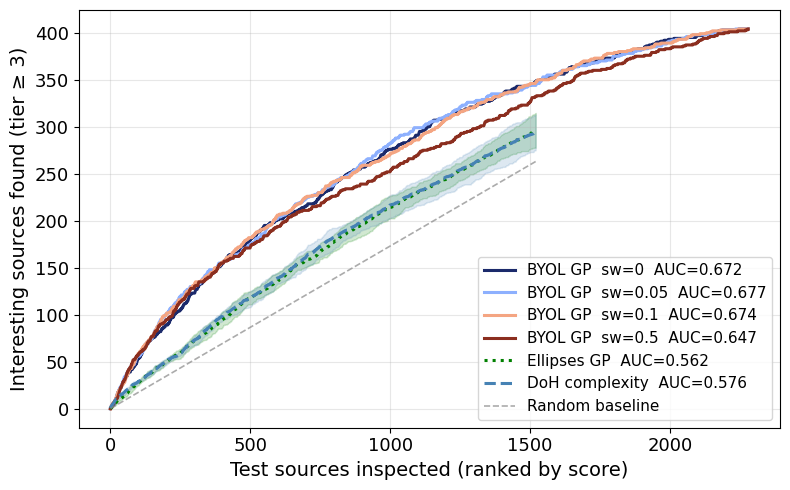

In [18]:
_bl_path = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{_data_seed_}.json"
print(f"Looking for baselines at: {_bl_path}")
if not _bl_path.exists():
    print(f"  → not found. Run §4.1 (Ellipses IsoForest Baseline) first.")
else:
    with open(_bl_path) as _fh:
        _bl = json.load(_fh)

    _ell_gp = _bl.get("ellipses_gp")
    _comp   = _bl.get("complexity")

    if _ell_gp is None:
        print("WARNING: ellipses_gp missing from baselines JSON. Re-run §4.1.")
    if _comp is None:
        print("WARNING: complexity missing from baselines JSON. Re-run §4.1.")

    # ── Helper: load BYOL GP scores from a protege dir ────────────────────────
    def _load_byol_parquet(protege_dir):
        for _sfx in ["proj_nopca", "proj_pca", _latent_tag, f"nb_{_latent_tag}_eps{EPSILON:g}"]:
            _p = protege_dir / f"protege_scores_{_sfx}.parquet"
            if _p.exists():
                return _p
        _candidates = sorted(protege_dir.glob("protege_scores_proj_*.parquet"))
        if _candidates:
            return _candidates[0]
        _candidates = sorted(protege_dir.glob("protege_scores_*.parquet"))
        return _candidates[0] if _candidates else None

    def _make_seed_test_set(seed_dir):
        """Derive (test_names, test_human) for the data_seed matching seed_dir.

        Expects directory layout: .../data_seed_<D>/training_seed_<N>/
        Falls back to the global _test_names / _test_human if the layout doesn't match.
        """
        try:
            _ds = int(seed_dir.parent.name.split('_')[-1])
            _ti = np.load(OUTPUTS_ROOT / "data_splits" / str(_ds) / "test_idx.npy")
            _tn = csv_df.iloc[_ti]["Source_Name"].values
            _ldf = pd.DataFrame(labels_all[_ti].astype(bool), columns=LABEL_COLS)
            _th  = np.ones(len(_ldf), dtype=int)
            for _sv, _cols in reversed(TIERS):
                _th[_ldf[_cols].any(axis=1).values] = _sv
            return _tn, _th
        except Exception as _e:
            print(f"    Warning: could not derive test set for {seed_dir.name} ({_e}), using global")
            return _test_names, _test_human

    def _byol_recall(parquet_path, test_names, test_human):
        df     = pd.read_parquet(parquet_path)
        common = [n for n in test_names if n in df.index]
        if len(common) < len(test_names):
            print(f"    Note: {len(test_names) - len(common)} test names absent from parquet")
        mask   = np.isin(test_names, common)
        scores = df.loc[common, "trained_score"].values
        th     = test_human[mask]
        ord_   = np.argsort(scores)[::-1]
        binary = (th[ord_] >= POSITIVE_THRESHOLD).astype(int)
        cum    = np.cumsum(binary)
        n_pos  = int(binary.sum())
        x      = np.arange(1, len(cum) + 1)
        auc    = float(np.trapezoid(cum, x) / (len(cum) * n_pos)) if n_pos > 0 else 0.0
        return x, cum, auc

    def _recall_band(cum_list):
        """68% CI band (16th–84th percentile) over a list of cumulative recall arrays."""
        min_len = min(len(c) for c in cum_list)
        arr = np.array([c[:min_len] for c in cum_list], dtype=float)
        return arr.mean(axis=0), np.percentile(arr, 16, axis=0), np.percentile(arr, 84, axis=0)

    def _load_all_seeds(family_dir):
        """Load recall curves for every diagonal seed, each evaluated on its own test set."""
        _seed_dirs = _get_diagonal_seed_dirs(family_dir) if family_dir.exists() else []
        if not _seed_dirs:
            _seed_dirs = [family_dir] if family_dir.exists() else []
        _results = []
        for _sd in _seed_dirs:
            _pq = _load_byol_parquet(_sd / "data" / "protege")
            if _pq is not None:
                try:
                    _tn, _th = _make_seed_test_set(_sd)
                    _results.append(_byol_recall(_pq, _tn, _th))
                except Exception as _e:
                    print(f"  Skipping {_sd.name}: {_e}")
        return _results

    # ── Main run — aggregate over all seeds ───────────────────────────────────
    _byol_all_seeds = _load_all_seeds(_run_dir)
    if _byol_all_seeds:
        _byol_cums = [c for _, c, _ in _byol_all_seeds]
        _byol_cum, _byol_cum_lo, _byol_cum_hi = _recall_band(_byol_cums)
        if len(_byol_all_seeds) == 1:
            _byol_cum_lo = _byol_cum_hi = None
        _byol_x   = _byol_all_seeds[0][0]
        _aucs_sw  = [a for _, _, a in _byol_all_seeds]
        _byol_auc = float(np.mean(_aucs_sw))
        _byol_auc_std = float(np.std(_aucs_sw))
        print(f"BYOL GP (sw={SUPERVISION_WEIGHT})  AUC={_byol_auc:.4f}  "
              f"(mean over {len(_byol_all_seeds)} seed(s), "
              f"range {min(_aucs_sw):.4f}–{max(_aucs_sw):.4f})")
    else:
        print(f"  → No BYOL GP parquet found in any seed under {_run_dir}")
        _byol_x = _byol_cum = _byol_auc = None
        _byol_cum_lo = _byol_cum_hi = None

    # ── Extra sw comparison runs (sw=0.0, 0.1, 0.5) ───────────────────────────
    _EXTRA_SW_VALUES  = [0.0, 0.1, 0.5]
    _sw_cividis       = {0.0: '#1B2A6B', 0.05: '#8DB0FE', 0.1: '#F4A582', 0.5: '#8B2E1F'}
    _extra_sw_results = {}

    _stem_for_glob = re.sub(r'_\d{8}_\d{4}', '', _run_dir.name)
    _stem_for_glob = re.sub(r'_sw[\d.]+',    '_sw*',  _stem_for_glob)
    _stem_for_glob = re.sub(r'_f[\d.]+',     '_f1',   _stem_for_glob)
    _all_sw_candidates = sorted(BYOL_RUNS_ROOT.glob(f"{_stem_for_glob}*"))

    for _sw_val in _EXTRA_SW_VALUES:
        if _sw_val == SUPERVISION_WEIGHT:
            continue

        _sw_dir = None
        for _cand in _all_sw_candidates:
            _m = re.search(r'_sw([\d.]+)[_/]', _cand.name + '_')
            if _m and abs(float(_m.group(1)) - _sw_val) < 1e-9:
                _sw_dir = _cand
                break

        if _sw_dir is None:
            print(f"  sw={_sw_val:g} f=1 run dir not found (glob: {_stem_for_glob})")
            continue

        _seeds = _load_all_seeds(_sw_dir)
        if _seeds:
            _cums = [c for _, c, _ in _seeds]
            _cum, _cum_lo, _cum_hi = _recall_band(_cums)
            if len(_seeds) == 1:
                _cum_lo = _cum_hi = None
            _aucs = [a for _, _, a in _seeds]
            _extra_sw_results[_sw_val] = dict(
                x=_seeds[0][0], cum=_cum, cum_lo=_cum_lo, cum_hi=_cum_hi,
                auc=float(np.mean(_aucs)), auc_std=float(np.std(_aucs)), n_seeds=len(_seeds),
            )
            print(f"BYOL GP (sw={_sw_val:g})               AUC={np.mean(_aucs):.4f}  "
                  f"(mean over {len(_seeds)} seed(s), "
                  f"range {min(_aucs):.4f}–{max(_aucs):.4f})")
        else:
            print(f"  sw={_sw_val:g} run found ({_sw_dir.name}) but has no parquets")

    # ── Load all available baselines_{seed}.json for Ellipses/Complexity bands ─
    _bl_dir = OUTPUTS_ROOT / "anomaly_baselines"
    _ell_cums_all  = []
    _comp_cums_all = []
    for _bl_p in sorted(_bl_dir.glob("baselines_*.json")):
        with open(_bl_p) as _fh:
            _bj = json.load(_fh)
        if _bj.get("ellipses_gp") is not None:
            _ell_cums_all.append(np.array(_bj["ellipses_gp"]["recall"], dtype=float))
        if _bj.get("complexity") is not None:
            _comp_cums_all.append(np.array(_bj["complexity"]["recall"], dtype=float))

    _n_bl_seeds = max(len(_ell_cums_all), len(_comp_cums_all))
    print(f"\nBaseline seeds found: {_n_bl_seeds}  "
          f"(ell={len(_ell_cums_all)}, comp={len(_comp_cums_all)})")

    if _ell_cums_all:
        _ell_cum_mean, _ell_cum_lo, _ell_cum_hi = _recall_band(_ell_cums_all)
        _ell_x_bl = np.arange(1, len(_ell_cum_mean) + 1)
        _ell_aucs_bl = [float(np.trapezoid(c, np.arange(1, len(c)+1)) / (len(c) * _bl["n_pos"]))
                        for c in _ell_cums_all if len(c) == len(_ell_cums_all[0])]
        _ell_auc_mean = float(np.mean(_ell_aucs_bl))
        _ell_auc_std  = float(np.std(_ell_aucs_bl))
        print(f"Ellipses GP  AUC={_ell_auc_mean:.4f} ± {_ell_auc_std:.4f}")
    else:
        # Fall back to single-seed curve already in _ell_gp
        _ell_cum_mean = np.array(_ell_gp['recall']) if _ell_gp else None
        _ell_cum_lo = _ell_cum_hi = None
        _ell_x_bl   = np.array(_ell_gp['x']) if _ell_gp else None
        _ell_auc_mean = _ell_gp['auc'] if _ell_gp else None
        _ell_auc_std  = 0.0

    if _comp_cums_all:
        _comp_cum_mean, _comp_cum_lo, _comp_cum_hi = _recall_band(_comp_cums_all)
        _comp_x_bl = np.arange(1, len(_comp_cum_mean) + 1)
        _comp_aucs_bl = [float(np.trapezoid(c, np.arange(1, len(c)+1)) / (len(c) * _bl["n_pos"]))
                         for c in _comp_cums_all if len(c) == len(_comp_cums_all[0])]
        _comp_auc_mean = float(np.mean(_comp_aucs_bl))
        _comp_auc_std  = float(np.std(_comp_aucs_bl))
        print(f"Complexity   AUC={_comp_auc_mean:.4f} ± {_comp_auc_std:.4f}")
    else:
        _comp_cum_mean = np.array(_comp['recall']) if _comp else None
        _comp_cum_lo = _comp_cum_hi = None
        _comp_x_bl   = np.array(_comp['x']) if _comp else None
        _comp_auc_mean = _comp['auc'] if _comp else None
        _comp_auc_std  = 0.0

    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))

    _all_sw_results = dict(_extra_sw_results)
    if _byol_cum is not None:
        _all_sw_results[SUPERVISION_WEIGHT] = dict(
            x=_byol_x, cum=_byol_cum, cum_lo=_byol_cum_lo, cum_hi=_byol_cum_hi,
            auc=_byol_auc, auc_std=_byol_auc_std, n_seeds=len(_byol_all_seeds),
        )
    for _sw_val in sorted(_all_sw_results):
        _r   = _all_sw_results[_sw_val]
        _col = _sw_cividis.get(_sw_val, '#888888')
        ax.plot(_r['x'], _r['cum'], color=_col, lw=2.2, ls='-',
                label=(f"BYOL GP  sw={_sw_val:g}  AUC={_r['auc']:.3f}"
                       + (f" \u00b1{_r['auc_std']:.3f}" if _r['n_seeds'] > 1 else "")))
        if _r['cum_lo'] is not None:
            ax.fill_between(_r['x'], _r['cum_lo'], _r['cum_hi'], color=_col, alpha=0.20)

    if _ell_cum_mean is not None:
        _ell_lbl = (f"Ellipses GP  AUC={_ell_auc_mean:.3f}"
                    + (f" \u00b1{_ell_auc_std:.3f}" if _ell_auc_std > 0 else ""))
        ax.plot(_ell_x_bl, _ell_cum_mean, color='green', lw=2.2, ls=':',
                label=_ell_lbl)
        if _ell_cum_lo is not None:
            ax.fill_between(_ell_x_bl, _ell_cum_lo, _ell_cum_hi, color='green', alpha=0.18)

    if _comp_cum_mean is not None:
        _comp_lbl = (f"DoH complexity  AUC={_comp_auc_mean:.3f}"
                     + (f" \u00b1{_comp_auc_std:.3f}" if _comp_auc_std > 0 else ""))
        ax.plot(_comp_x_bl, _comp_cum_mean, color='steelblue', lw=2.2, ls='--',
                label=_comp_lbl)
        if _comp_cum_lo is not None:
            ax.fill_between(_comp_x_bl, _comp_cum_lo, _comp_cum_hi,
                            color='steelblue', alpha=0.18)

    _n_eval_bl = _bl["n_eval"]
    _n_pos_bl  = _bl["n_pos"]
    ax.plot(np.arange(1, _n_eval_bl + 1),
            np.arange(1, _n_eval_bl + 1) * (_n_pos_bl / _n_eval_bl),
            color='#888888', ls='--', lw=1.2, alpha=0.7, label='Random baseline')

    ax.set_xlabel('Test sources inspected (ranked by score)', fontsize=14)
    ax.set_ylabel(f'Interesting sources found (tier ≥ {POSITIVE_THRESHOLD})', fontsize=14)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    _fig_dir = OUTPUTS_ROOT / 'figures' / 'protege'
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / 'byol_ell_comparison.png', dpi=150, bbox_inches='tight')
    _pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
    _pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pdf_dir / "byol_ell_comparison.pdf", bbox_inches="tight")
    plt.show()

### 3.4 Sweep Data Loading

Loads all pre-computed Protege scores from parquet files matching `RUN_GLOB`. For each run, parses `f`, `sw`, `vicregvar`, `cov`, and `gamma` from the directory name and reads AUC metrics from the corresponding `protege_summary_nopca.json`. Results are collected into `protege_results` for the ablation plots below.

Found 16 family dirs → 16 run dirs
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.05_f0.1  latent=proj  (f=0.1, sw=0.05)  auc=0.6708
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.05_f0.1  latent=enc  (f=0.1, sw=0.05)  auc=0.5753
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  latent=proj  (f=1.0, sw=0.05)  auc=0.6766
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  latent=enc  (f=1.0, sw=0.05)  auc=0.5624
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.0_f0.1  latent=proj  (f=0.1, sw=0.0)  auc=0.6747


  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.0_f0.1  latent=enc  (f=0.1, sw=0.0)  auc=0.6787
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1  latent=proj  (f=1.0, sw=0.0)  auc=0.6721
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1  latent=enc  (f=1.0, sw=0.0)  auc=0.6673
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.1_f0.1  latent=proj  (f=0.1, sw=0.1)  auc=0.6715


  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.1_f0.1  latent=enc  (f=0.1, sw=0.1)  auc=0.5763
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1  latent=proj  (f=1.0, sw=0.1)  auc=0.6745
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1  latent=enc  (f=1.0, sw=0.1)  auc=0.5665
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.5_f0.1  latent=proj  (f=0.1, sw=0.5)  auc=0.6722
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.5_f0.1  latent=enc  (f=0.1, sw=0.5)  auc=0.5752
  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  latent=proj  (f=1.0, sw=0.5)  auc=0.6467


  loaded pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  latent=enc  (f=1.0, sw=0.5)  auc=0.5650
  loaded pd128_qext_v1_wd1e-3_lrconst_sw1.0_f0.1  latent=proj  (f=0.1, sw=1.0)  auc=0.6588
  loaded pd128_qext_v1_wd1e-3_lrconst_sw1.0_f0.1  latent=enc  (f=0.1, sw=1.0)  auc=0.6621


  loaded pd128_qext_v1_wd1e-3_lrconst_sw1.0_f1  latent=proj  (f=1.0, sw=1.0)  auc=0.6518
  loaded pd128_qext_v1_wd1e-3_lrconst_sw1.0_f1  latent=enc  (f=1.0, sw=1.0)  auc=0.5584

Loaded 20 Protege run×latent entries.

Pre-computing recall curves...


Seed-averaged: 20 entries → 20 (name, latent) groups


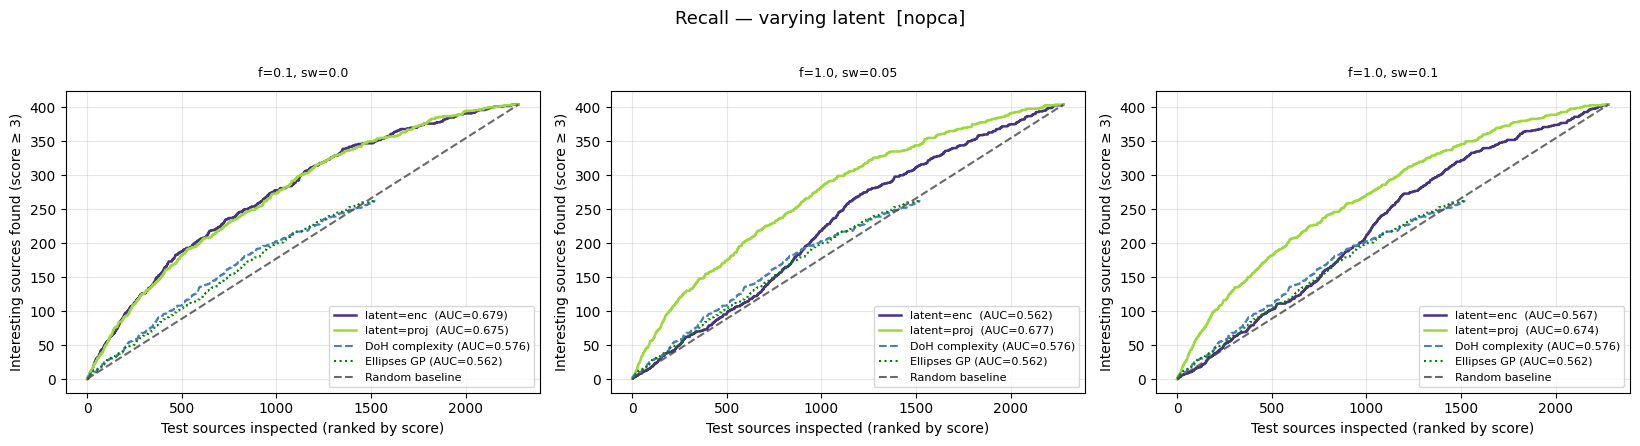

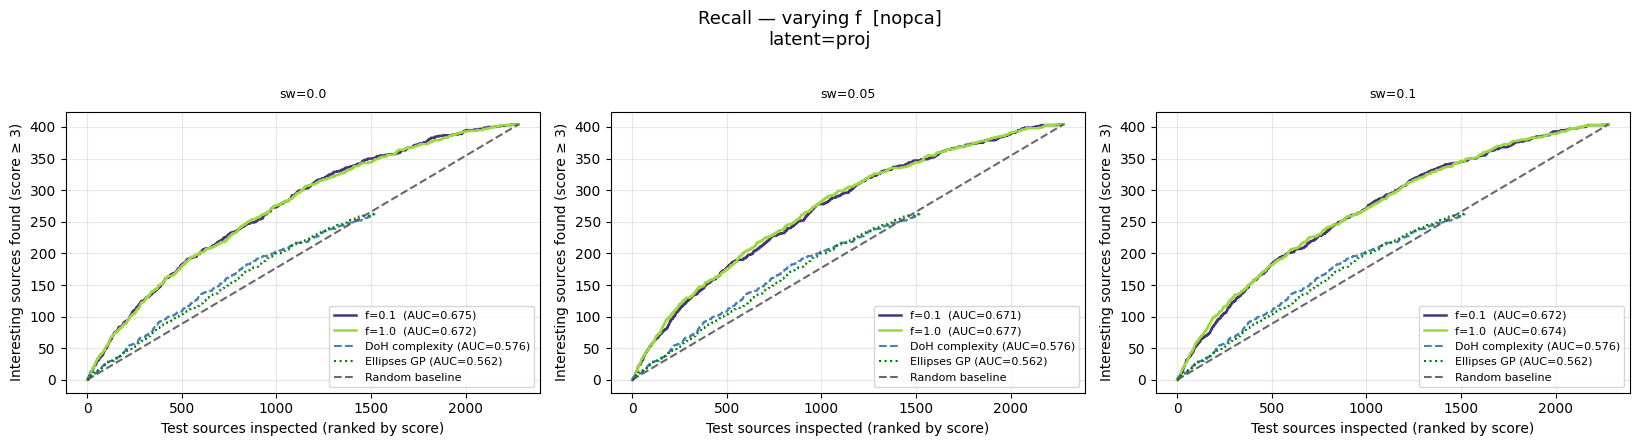

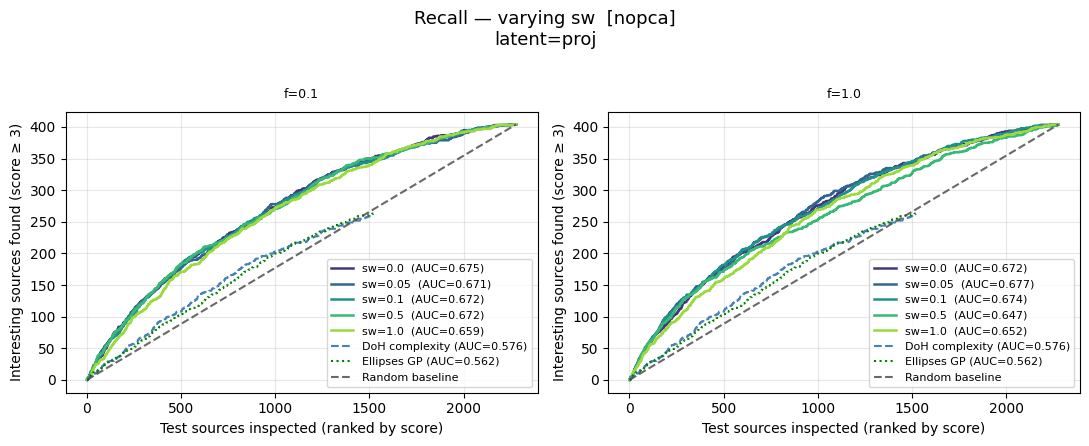


Run                                        lat      f    ema      sw  seeds  test_AUC  train_AUC
----------------------------------------------------------------------------------------------
pd128_qext_v1_wd1e-3_lrconst_sw0.0_f0.1    enc   0.10   None   0.000      1    0.6787     0.7330
pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1    proj   1.00   None   0.050      1    0.6766     0.7350
pd128_qext_v1_wd1e-3_lrconst_sw0.0_f0.1   proj   0.10   None   0.000      1    0.6747     0.7110
pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1     proj   1.00   None   0.100      1    0.6745     0.7378
pd128_qext_v1_wd1e-3_lrconst_sw0.5_f0.1   proj   0.10   None   0.500      1    0.6722     0.7240
pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1     proj   1.00   None   0.000      1    0.6721     0.7342
pd128_qext_v1_wd1e-3_lrconst_sw0.1_f0.1   proj   0.10   None   0.100      1    0.6715     0.7198
pd128_qext_v1_wd1e-3_lrconst_sw0.05_f0.1  proj   0.10   None   0.050      1    0.6708     0.7245
pd128_qext_v1_wd1e-3_lrconst_sw

In [19]:
# ── Protege Sweep Config ──────────────────────────────────────────────────────
LABELS_PATH = LABELS_NPY_PATH   # alias
PROTEGE_PCA = "nopca"           # "nopca" = raw features, "pca" = PCA-reduced (for proj)

# Glob pattern for the sweep — matches family-level dirs (seed subdirs expanded below)
SWEEP_GLOBS = [
    "pd128_qext_v1_wd1e-3_lrconst_sw*_f*",
]

# Both latent types are tried for every run; whichever parquets exist are loaded.
# proj uses PROTEGE_PCA tag; enc is always PCA-reduced (1280-dim → PCA before GP).
PROTEGE_LATENTS = ["proj", "enc"]

def _latent_pca_tag(latent):
    """Return the pca suffix tag used when saving files for this latent."""
    return "pca" if latent == "enc" else PROTEGE_PCA

# ── Load all protege scores ───────────────────────────────────────────────────
_csv_df     = pd.read_csv(CSV_PATH)
_labels_all = np.load(LABELS_PATH)

def _load_test_idx(rd, data_seed):
    """Load test_idx.npy from shared splits dir (new runs) or data dir (old runs)."""
    p = OUTPUTS_ROOT / "data_splits" / str(data_seed) / "test_idx.npy"
    return np.load(p if p.exists() else rd / "data" / "test_idx.npy")

def _read_data_seed(rd):
    """Read data_seed from checkpoint config."""
    ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    return int(ckpt["config"]["data_seed"])

# Expand family-level dirs to diagonal seed dirs
def _expand_to_run_dirs(family_dirs):
    run_dirs = []
    for fd in family_dirs:
        diag = _get_diagonal_seed_dirs(fd)
        if diag:
            run_dirs.extend(diag)
    return run_dirs

_family_dirs = sorted({rd for g in SWEEP_GLOBS for rd in BYOL_RUNS_ROOT.glob(g)})
_run_dirs    = _expand_to_run_dirs(_family_dirs)
print(f"Found {len(_family_dirs)} family dirs → {len(_run_dirs)} run dirs")

protege_results = []
for rd in _run_dirs:
    _name_for_regex = rd.parent.parent.name
    m_f  = re.search(r'_f([\d.]+)', _name_for_regex)
    m_sw = re.search(r'_sw([\d.]+)', _name_for_regex)
    if not m_f or not m_sw:
        continue
    f_val  = float(m_f.group(1))
    sw_val = float(m_sw.group(1))

    m_ema = re.search(r'_ema([\d.]+)', _name_for_regex)
    m_vv  = re.search(r'_vicregvar([\d.]+)', _name_for_regex)
    m_cov = re.search(r'_cov([\d.]+)', _name_for_regex)
    m_gam = re.search(r'_gamma([\d.]+)', _name_for_regex)
    ema       = float(m_ema.group(1)) if m_ema else None
    vicregvar = float(m_vv.group(1))  if m_vv  else None
    cov       = float(m_cov.group(1)) if m_cov else None
    gamma     = float(m_gam.group(1)) if m_gam else None

    m_model = re.match(r'run_(\w+)_', _name_for_regex)
    model   = m_model.group(1) if m_model else None

    m_enc = re.match(r'run_\w+_(\w+)(?:_(pd\d+))?_(pond|clos)_', _name_for_regex)
    if m_enc:
        _proj   = m_enc.group(1)
        _pdim   = m_enc.group(2)
        aug     = m_enc.group(3)
        encoder = f"{_proj}_{_pdim}" if _pdim else _proj
    else:
        aug = encoder = None

    _protege_dir = rd / "data" / "protege"

    for latent in PROTEGE_LATENTS:
        _ptag = _latent_pca_tag(latent)
        scores_path = summary_path = None
        for _sfx in [f"{latent}_{_ptag}", _ptag]:
            _sp = _protege_dir / f"protege_scores_{_sfx}.parquet"
            _su = _protege_dir / f"protege_summary_{_sfx}.json"
            if _sp.exists():
                scores_path  = _sp
                summary_path = _su if _su.exists() else None
                break

        if scores_path is None:
            continue

        active_output = pd.read_parquet(scores_path)

        if summary_path is not None:
            with open(summary_path) as fh:
                summary = json.load(fh)
            n_eval    = summary["n_eval"]
            n_pos     = summary["n_eval_positives"]
            auc       = summary.get("test_auc")
            train_auc = summary.get("train_auc")
            data_seed = summary.get("data_seed") or _read_data_seed(rd)
        else:
            data_seed = _read_data_seed(rd)
            _test_idx = _load_test_idx(rd, data_seed)
            _ldf      = pd.DataFrame(_labels_all[_test_idx].astype(bool), columns=LABEL_COLS)
            _hl       = np.ones(len(_ldf), dtype=int)
            for _sv, _cols in reversed(TIERS):
                _hl[_ldf[_cols].any(axis=1).values] = _sv
            n_eval    = len(_test_idx)
            n_pos     = int((_hl >= POSITIVE_THRESHOLD).sum())
            auc       = train_auc = None

        protege_results.append(dict(
            name=_name_for_regex, rd=rd,
            f=f_val, sw=sw_val, ema=ema, vicregvar=vicregvar, cov=cov, gamma=gamma,
            model=model, aug=aug, encoder=encoder, latent=latent,
            active_output=active_output,
            n_eval=n_eval, n_pos=n_pos, auc=auc, train_auc=train_auc,
            data_seed=data_seed,
        ))
        auc_s = f"  auc={auc:.4f}" if auc is not None else ""
        print(f"  loaded {_name_for_regex}  latent={latent}  (f={f_val}, sw={sw_val}){auc_s}")

print(f"\nLoaded {len(protege_results)} Protege run×latent entries.")

# ── Helpers ───────────────────────────────────────────────────────────────────
def _test_recall(r):
    """Return (x, cum, auc, n_pos) on r's test set using active_output scores."""
    test_idx    = _load_test_idx(r["rd"], r["data_seed"])
    src_names   = _csv_df.iloc[test_idx]["Source_Name"].values
    ldf         = pd.DataFrame(_labels_all[test_idx].astype(bool), columns=LABEL_COLS)
    hl          = np.ones(len(ldf), dtype=int)
    for sv, cols in reversed(TIERS):
        hl[ldf[cols].any(axis=1).values] = sv
    true_labels = pd.Series(hl, index=src_names)
    ao          = r["active_output"]
    test_srcs   = [n for n in src_names if n in ao.index]
    ranked      = ao.loc[test_srcs].sort_values("trained_score", ascending=False)
    binary      = (true_labels.loc[ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    cum         = np.cumsum(binary)
    n, n_pos_   = len(cum), int(binary.sum())
    x           = np.arange(1, n + 1)
    auc_        = float(np.trapezoid(cum, x) / (n * n_pos_)) if n_pos_ > 0 else 0.0
    return x, cum, auc_, n_pos_

_baselines_cache = {}
def _get_baselines(r):
    seed = r["data_seed"]
    if seed not in _baselines_cache:
        bp = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{seed}.json"
        _baselines_cache[seed] = json.load(open(bp)) if bp.exists() else None
    return _baselines_cache[seed]

# ── Pre-compute recall curves & seed-average ─────────────────────────────────
# All runs with the same family name and latent but different training seeds are
# averaged; the 68% uncertainty band is ±1 std dev across seeds.
print("\nPre-computing recall curves...")
for r in protege_results:
    r["_x"], r["_cum"], r["_auc_live"], r["_n_pos_live"] = _test_recall(r)
    if r["auc"] is None:
        r["auc"] = r["_auc_live"]

_seed_groups = defaultdict(list)
for r in protege_results:
    _seed_groups[(r["name"], r["latent"])].append(r)

protege_averaged = []
for (name, latent), runs in sorted(_seed_groups.items()):
    r0 = runs[0]
    if len(runs) > 1:
        cums           = np.array([r["_cum"] for r in runs], dtype=float)
        mean_cum       = cums.mean(axis=0)
        std_cum        = cums.std(axis=0)
        mean_auc       = float(np.mean([r["_auc_live"] for r in runs]))
        _tauc_vals     = [r["train_auc"] for r in runs if r["train_auc"] is not None]
        mean_train_auc = float(np.mean(_tauc_vals)) if _tauc_vals else None
    else:
        mean_cum       = r0["_cum"].astype(float)
        std_cum        = np.zeros_like(mean_cum)
        mean_auc       = r0["_auc_live"]
        mean_train_auc = r0["train_auc"]
    entry = dict(r0)
    entry.update(
        n_seeds=len(runs),
        _mean_cum=mean_cum, _std_cum=std_cum, _mean_x=r0["_x"],
        auc=mean_auc, train_auc=mean_train_auc,
    )
    protege_averaged.append(entry)

print(f"Seed-averaged: {len(protege_results)} entries → {len(protege_averaged)} (name, latent) groups")

if not protege_averaged:
    print("No Protege scores available.")
else:
    VARY_PARAMS = ["latent", "f", "ema", "sw", "vicregvar", "cov", "gamma", "encoder", "aug", "model"]
    _sweep_dir  = OUTPUTS_ROOT / "figures" / "protege"
    _sweep_dir.mkdir(parents=True, exist_ok=True)

    # Lookup enc-averaged entry by family name for top-row dual-latent overlay
    _enc_avg_lookup = {r["name"]: r for r in protege_averaged if r["latent"] == "enc"}

    for vary_p in VARY_PARAMS:
        other_params = [p for p in VARY_PARAMS if p != vary_p]

        # Non-latent sweeps: use only proj entries (enc shown separately in top row)
        _base = protege_averaged if vary_p == "latent" else [
            r for r in protege_averaged if r["latent"] == "proj"]

        groups = defaultdict(list)
        for r in _base:
            if r[vary_p] is None:
                continue
            key = tuple(r[p] for p in other_params)
            groups[key].append(r)

        valid = {k: v for k, v in groups.items()
                 if len({r[vary_p] for r in v}) >= 2}
        if not valid:
            continue

        def _peak_auc(runs):
            vals = [r["auc"] for r in runs if r["auc"] is not None]
            return max(vals) if vals else -1.0

        if len(valid) > 3:
            valid = dict(sorted(valid.items(), key=lambda kv: -_peak_auc(kv[1]))[:3])

        valid_keys = list(valid.keys())
        shared_parts   = []
        differ_indices = []
        for pi, p in enumerate(other_params):
            vals_for_p = {k[pi] for k in valid_keys}
            if len(vals_for_p) == 1:
                v = next(iter(vals_for_p))
                if v is not None:
                    shared_parts.append(f"{p}={v}")
            else:
                differ_indices.append(pi)

        all_vals = sorted({r[vary_p] for v in valid.values() for r in v},
                          key=lambda x: str(x))
        cmap_v  = plt.cm.viridis(np.linspace(0.15, 0.85, len(all_vals)))
        val_clr = {v: cmap_v[i] for i, v in enumerate(all_vals)}

        n_groups = len(valid)
        ncols    = min(n_groups, 3)
        nrows    = (n_groups + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols,
                                  figsize=(ncols * 5.5, nrows * 4.5), sharey=False)
        axes = np.array(axes).reshape(nrows, ncols)

        for ax_i, (fixed_key, group) in enumerate(sorted(valid.items(), key=str)):
            ax         = axes[ax_i // ncols, ax_i % ncols]

            differ_parts = [f"{other_params[pi]}={fixed_key[pi]}"
                            for pi in differ_indices if fixed_key[pi] is not None]
            ax.set_title(", ".join(differ_parts) if differ_parts else vary_p,
                         fontsize=9, pad=10)

            for r in sorted(group, key=lambda x: str(x[vary_p])):
                clr      = val_clr[r[vary_p]]
                x        = r["_mean_x"]
                mean_cum = r["_mean_cum"]
                std_cum  = r["_std_cum"]
                n_pos_   = r["n_pos"]
                n_seeds  = r["n_seeds"]
                seed_sfx = f"  [n={n_seeds}]" if n_seeds > 1 else ""
                lbl_proj = (f"{vary_p}={r[vary_p]}  (AUC={r['auc']:.3f}){seed_sfx}"
                         if vary_p == "latent" else
                         f"{vary_p}={r[vary_p]}  (AUC={r['auc']:.3f}){seed_sfx}")

                ax.plot(x, mean_cum, color=clr, linewidth=1.8, label=lbl_proj)
                if n_seeds > 1:
                    ax.fill_between(x,
                                    np.clip(mean_cum - std_cum, 0, n_pos_),
                                    np.clip(mean_cum + std_cum, 0, n_pos_),
                                    color=clr, alpha=0.2)


            r0  = group[0]
            bl  = _get_baselines(r0)
            n_  = r0["n_eval"]
            np_ = r0["n_pos"]

            if bl:
                if bl.get("complexity"):
                    ax.plot(bl["complexity"]["x"], bl["complexity"]["recall"],
                            color="steelblue", linewidth=1.5, linestyle="--",
                            label=f"DoH complexity (AUC={bl['complexity']['auc']:.3f})")
                if bl.get("ellipses_gp"):
                    ax.plot(bl["ellipses_gp"]["x"], bl["ellipses_gp"]["recall"],
                            color="green", linewidth=1.5, linestyle=":",
                            label=f"Ellipses GP (AUC={bl['ellipses_gp']['auc']:.3f})")

            ax.plot(np.arange(1, n_ + 1), np.arange(1, n_ + 1) * (np_ / n_),
                    color="#444444", linestyle="--", linewidth=1.5, alpha=0.8,
                    label="Random baseline")

            ax.set_xlabel("Test sources inspected (ranked by score)")
            ax.set_ylabel(f"Interesting sources found (score ≥ {POSITIVE_THRESHOLD})")
            ax.legend(fontsize=8, loc="lower right")
            ax.grid(True, alpha=0.3)

        for idx in range(n_groups, nrows * ncols):
            axes[idx // ncols, idx % ncols].set_visible(False)

        suptitle = f"Recall — varying {vary_p}  [{PROTEGE_PCA}]"
        if shared_parts:
            suptitle += "\n" + ", ".join(shared_parts)
        fig.suptitle(suptitle, fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    if any(r["auc"] is not None for r in protege_averaged):
        w = max(len(r["name"]) for r in protege_averaged)
        print(f"\n{'Run':<{w}}  {'lat':>4}  {'f':>5}  {'ema':>5}  {'sw':>6}  {'seeds':>5}  {'test_AUC':>8}  {'train_AUC':>9}")
        print("-" * (w + 54))
        for r in sorted(protege_averaged, key=lambda x: -(x["auc"] or 0)):
            auc_s  = f"{r['auc']:>8.4f}"
            tauc_s = f"{r['train_auc']:>9.4f}" if r["train_auc"] is not None else "      N/A"
            print(f"{r['name']:<{w}}  {r['latent']:>4}  {r['f']:>5.2f}  "
                  f"{str(r['ema']):>5}  {r['sw']:>6.3f}  {r['n_seeds']:>5}  {auc_s}  {tauc_s}")

### 3.5 Noise Robustness Test

Evaluates BYOL GP and Ellipses GP on test images with injected Gaussian noise. Real-valued Gaussian noise is Hermitian-symmetric in Fourier space, matching the statistical structure of interferometric noise.

Noise is parameterised as a multiple σ of each source image's own pixel standard deviation, making it scale-invariant across the dataset. The GP is trained once on clean training data and then scored on noisy test features at each σ — equivalent to testing degradation robustness.

All AUCs are pre-computed by `scripts/compute_noise_robustness.py`; run `sbatch jobs/sbatch_compute_noise_robustness.sh` to generate them.

sw=0.0: 1 seed(s)  σ=0 AUC=0.6721
sw=0.05: 1 seed(s)  σ=0 AUC=0.6766
sw=0.1: 1 seed(s)  σ=0 AUC=0.6745
sw=0.5: 1 seed(s)  σ=0 AUC=0.6467

Ellipses GP σ=0 AUC : 0.5801  (1 seed(s))
Complexity  σ=0 AUC : 0.5724  (1 seed(s))


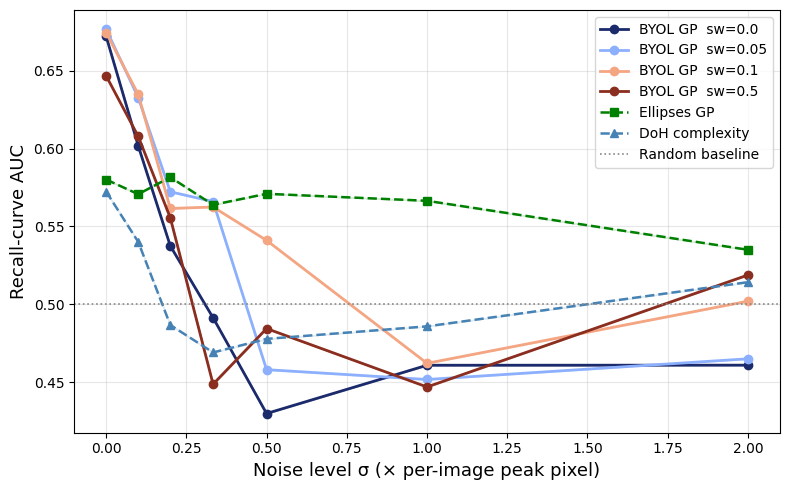


σ              sw=0.0       sw=0.05        sw=0.1        sw=0.5   Ellipses GP    Complexity
───────────────────────────────────────────────────────────────────────────────────────────
0.000          0.6721        0.6766        0.6745        0.6467        0.5801        0.5724
0.100          0.6018        0.6328        0.6348        0.6078        0.5707        0.5401
0.200          0.5375        0.5722        0.5615        0.5555        0.5816        0.4867
0.333          0.4913        0.5660        0.5625        0.4487        0.5639        0.4691
0.500          0.4299        0.4580        0.5411        0.4844        0.5710        0.4778
1.000          0.4609        0.4517        0.4621        0.4469        0.5665        0.4858
2.000          0.4609        0.4650        0.5020        0.5188        0.5350        0.5142


In [20]:
# ── Noise robustness plot ──────────────────────────────────────────────────────
# All AUCs pre-computed by scripts/compute_noise_robustness.py.
# Run:  sbatch jobs/sbatch_compute_noise_robustness.sh
#
# Shows BYOL GP for each sw value, averaged across all available training seeds.
# Ellipses GP and Complexity are shared (independent of BYOL model) but still
# vary across data splits, so their bands come from the per-seed JSONs too,
# deduplicated by data_seed to avoid counting the same split more than once.

_nr_byol_runs_root = BYOL_RUNS_ROOT   # outputs/byol_runs/
_NR_SW_VALUES = [0.0, 0.05, 0.1, 0.5]
_NR_RUN_TEMPLATE = "pd128_qext_v1_wd1e-3_lrconst_sw{sw}_f1"

_nr_colors = {0.0: "#1B2A6B", 0.05: "#8DB0FE", 0.1: "#F4A582", 0.5: "#8B2E1F"}  # cividis 4-pt

# ── Load per-sw data ──────────────────────────────────────────────────────────
NOISE_SIGMAS     = None
_nr_byol_data    = {}   # sw → {"aucs": [...], "lo16": [...], "hi84": [...], "n_seeds": int}
_nr_ell_by_seed  = {}   # data_seed → np.array(n_sigmas) — deduplicated across sw
_nr_comp_by_seed = {}   # data_seed → np.array(n_sigmas)

for _sw in _NR_SW_VALUES:
    _sw_str  = str(_sw)
    _run_dir = _nr_byol_runs_root / _NR_RUN_TEMPLATE.format(sw=_sw_str)
    _jsons   = sorted(
        sd / "data" / "anomaly" / "noise_robustness.json"
        for sd in _get_diagonal_seed_dirs(_run_dir)
        if (sd / "data" / "anomaly" / "noise_robustness.json").exists()
    )
    if not _jsons:
        print(f"sw={_sw}: no noise_robustness.json found under {_run_dir}")
        continue

    _seed_aucs = []   # list of byol_auc arrays (one per seed)
    for _p in _jsons:
        with open(_p) as _fh:
            _d = json.load(_fh)
        if NOISE_SIGMAS is None:
            NOISE_SIGMAS = _d["noise_sigmas"]
        elif _d["noise_sigmas"] != NOISE_SIGMAS:
            print(f"  skipping {_p.parent.parent.name}: sigma mismatch {_d['noise_sigmas']} vs {NOISE_SIGMAS}")
            continue
        _seed_aucs.append(np.array(_d["byol_auc"]))

        # Collect ellipses/complexity by data_seed (same split gives same result
        # regardless of sw, so deduplicate to avoid re-counting)
        _dseed = _d.get("data_seed")
        if _dseed is not None and _dseed not in _nr_ell_by_seed:
            if "ell_auc" in _d:
                _nr_ell_by_seed[_dseed]  = np.array(_d["ell_auc"])
            if "complexity_auc" in _d:
                _nr_comp_by_seed[_dseed] = np.array(_d["complexity_auc"])

    _mat      = np.stack(_seed_aucs, axis=0)   # (n_seeds, n_sigmas)
    _mean_auc = _mat.mean(axis=0).tolist()
    _lo16_auc = np.percentile(_mat, 16, axis=0).tolist()
    _hi84_auc = np.percentile(_mat, 84, axis=0).tolist()
    _nr_byol_data[_sw] = {"aucs": _mean_auc, "lo16": _lo16_auc, "hi84": _hi84_auc,
                           "n_seeds": len(_seed_aucs)}
    print(f"sw={_sw}: {len(_seed_aucs)} seed(s)  σ=0 AUC={_mean_auc[0]:.4f}")

# ── Aggregate ellipses / complexity across data seeds ─────────────────────────
_nr_ell_auc  = _nr_ell_lo16  = _nr_ell_hi84  = None
_nr_comp_aucs = _nr_comp_lo16 = _nr_comp_hi84 = None

if _nr_ell_by_seed:
    _ell_mat     = np.stack(list(_nr_ell_by_seed.values()), axis=0)
    _nr_ell_auc  = _ell_mat.mean(axis=0).tolist()
    _nr_ell_lo16 = np.percentile(_ell_mat, 16, axis=0).tolist()
    _nr_ell_hi84 = np.percentile(_ell_mat, 84, axis=0).tolist()

if _nr_comp_by_seed:
    _comp_mat     = np.stack(list(_nr_comp_by_seed.values()), axis=0)
    _nr_comp_aucs = _comp_mat.mean(axis=0).tolist()
    _nr_comp_lo16 = np.percentile(_comp_mat, 16, axis=0).tolist()
    _nr_comp_hi84 = np.percentile(_comp_mat, 84, axis=0).tolist()

if NOISE_SIGMAS is None:
    print("\nNo data found. Run:  sbatch jobs/sbatch_compute_noise_robustness.sh")
else:
    _n_ell  = len(_nr_ell_by_seed)
    _n_comp = len(_nr_comp_by_seed)
    print(f"\nEllipses GP σ=0 AUC : {_nr_ell_auc[0]:.4f}  ({_n_ell} seed(s))"   if _nr_ell_auc  else "Ellipses: not found")
    print(f"Complexity  σ=0 AUC : {_nr_comp_aucs[0]:.4f}  ({_n_comp} seed(s))" if _nr_comp_aucs else "Complexity: not found")

# ── Plot ──────────────────────────────────────────────────────────────────────
if NOISE_SIGMAS is not None:
    fig, ax = plt.subplots(figsize=(8, 5))

    for _sw in _NR_SW_VALUES:
        if _sw not in _nr_byol_data:
            continue
        _d   = _nr_byol_data[_sw]
        _col = _nr_colors[_sw]
        ax.plot(NOISE_SIGMAS, _d["aucs"], "o-", color=_col, linewidth=2,
                label=f"BYOL GP  sw={_sw}")
        ax.fill_between(NOISE_SIGMAS, _d["lo16"], _d["hi84"], color=_col, alpha=0.18)

    if _nr_ell_auc is not None:
        ax.plot(NOISE_SIGMAS, _nr_ell_auc, "s--", color="green", linewidth=1.8,
                label="Ellipses GP")
        if _nr_ell_lo16 is not None:
            ax.fill_between(NOISE_SIGMAS, _nr_ell_lo16, _nr_ell_hi84,
                            color="green", alpha=0.15)
    if _nr_comp_aucs is not None:
        ax.plot(NOISE_SIGMAS, _nr_comp_aucs, "^--", color="steelblue", linewidth=1.8,
                label="DoH complexity")
        if _nr_comp_lo16 is not None:
            ax.fill_between(NOISE_SIGMAS, _nr_comp_lo16, _nr_comp_hi84,
                            color="steelblue", alpha=0.15)

    ax.axhline(0.5, color="#888888", linestyle=":", linewidth=1.2, label="Random baseline")
    ax.set_xlabel("Noise level σ (× per-image peak pixel)", fontsize=13)
    ax.set_ylabel("Recall-curve AUC", fontsize=13)

    # Auto-scale y-axis to all plotted values with a small margin
    _nr_all_vals = []
    for _d in _nr_byol_data.values():
        _nr_all_vals.extend(_d["lo16"])
        _nr_all_vals.extend(_d["hi84"])
    for _lo, _hi in [(_nr_ell_lo16, _nr_ell_hi84), (_nr_comp_lo16, _nr_comp_hi84)]:
        if _lo is not None:
            _nr_all_vals.extend(_lo)
            _nr_all_vals.extend(_hi)
    _nr_all_vals.append(0.5)   # include random baseline
    _nr_ymin = min(_nr_all_vals)
    _nr_ymax = max(_nr_all_vals)
    _nr_margin = 0.05 * (_nr_ymax - _nr_ymin) if _nr_ymax > _nr_ymin else 0.02
    ax.set_ylim([_nr_ymin - _nr_margin, min(1.0, _nr_ymax + _nr_margin)])

    ax.legend(fontsize=10, loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _nr_fig_dir = OUTPUTS_ROOT / "figures" / "noise_robustness"
    _nr_fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_nr_fig_dir / "auc_vs_noise.png", dpi=150, bbox_inches="tight")
    _pdf_dir = OUTPUTS_ROOT / "figures" / "rare_object_detection.ipynb"
    _pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pdf_dir / "auc_vs_noise.pdf", bbox_inches="tight")
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    _nr_sw_cols  = [f"sw={s}" for s in _NR_SW_VALUES]
    _nr_all_cols = _nr_sw_cols + ["Ellipses GP", "Complexity"]
    _nr_col_w    = 14
    print(f"\n{'σ':<7}", end="")
    for _c in _nr_all_cols:
        print(f"{_c:>{_nr_col_w}}", end="")
    print()
    print("─" * (7 + _nr_col_w * len(_nr_all_cols)))
    for _si, _sig in enumerate(NOISE_SIGMAS):
        print(f"{_sig:<7.3f}", end="")
        for _sw in _NR_SW_VALUES:
            _v = _nr_byol_data[_sw]["aucs"][_si] if _sw in _nr_byol_data else None
            print(f"{'N/A' if _v is None else f'{_v:.4f}':>{_nr_col_w}}", end="")
        for _vals in [_nr_ell_auc, _nr_comp_aucs]:
            _v = _vals[_si] if (_vals is not None and _si < len(_vals)) else None
            print(f"{'N/A' if _v is None else f'{_v:.4f}':>{_nr_col_w}}", end="")
        print()

## 4. Interactive Protege Fine-Tuning

Select one run from the sweep results, warm-start the GP from its existing labels, then label new sources interactively to improve recall.

In [21]:
raise SystemExit("Stop here — interactive fine-tuning section below.")

SystemExit: Stop here — interactive fine-tuning section below.

/users/mbredber/p3_SUPLAT/.venv/lib64/python3.11/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
